# Trabajo Práctico Final - Análisis de Series de Tiempo

**Curso:** Análisis de Series de Tiempo (02MIA2026)

**Docente:** Camilo Argoty

**Alumnos:** Gustavo Rivas, Carlos Rivas, Fermín Rodríguez

**Dataset:** Producción Eléctrica Mensual de Argentina, filtrada del dataset global "Electricity Production Dataset" (Kaggle - https://www.kaggle.com/datasets/sazidthe1/global-electricity-production), que cubre 48 países con registros mensuales de producción eléctrica (GWh) entre 2010 y 2023, con columnas `Country`, `Date` y `Production`. **Nota:** una vez filtrado por Argentina y por el parámetro *Net Electricity Production*, la serie efectiva utilizada abarca **108 meses entre enero de 2015 y diciembre de 2023** (los meses previos a 2015 no están reportados para el país).

**Objetivo:** Analizar la serie temporal de generación eléctrica mensual de Argentina, construir y comparar cuatro modelos de pronóstico diferentes (ARIMA, SARIMA, Holt-Winters y Prophet), y responder a una pregunta de investigación basada en los resultados.

## Contenido:
1. Importación de Librerías
2. Carga y Preparación de Datos
3. Análisis de Calidad de Datos
4. Visualización Inicial de la Serie Temporal
5. Análisis de Componentes de la Serie
6. Implementación de Modelos de Pronóstico
7. Comparación de Modelos
8. Informe Final / Conclusiones

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para las gráficas
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

### Importación de Componentes Estadísticos

Importamos los componentes específicos de `statsmodels` necesarios para el análisis de series temporales:

- Componentes para pruebas de estacionariedad
- Funciones para descomposición de series
- Modelos ARIMA, SARIMA y Holt-Winters, y sus herramientas de diagnóstico

In [2]:
# Componentes de statsmodels
import statsmodels.api as sm
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Para pruebas de estacionariedad
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats

## 2. Carga y Preparación de Datos

### Descripción del Dataset

Utilizamos el dataset **"Electricity Production Dataset"** publicado en Kaggle por *sazidthe1*:

- **Fuente**: https://www.kaggle.com/datasets/sazidthe1/global-electricity-production
- **Cobertura**: producción eléctrica mensual de 48 países, entre 2010 y 2023 (la serie de **Argentina** efectivamente disponible es **2015-2023**, 108 meses)
- **Columnas principales**: `Country` (país), `Date` (fecha del registro mensual), `Production` (producción eléctrica, en GWh)

Este dataset es **multi-país**, por lo que necesitamos **filtrar únicamente los registros de Argentina**,
de forma que quede una serie mensual univariada (`Production`).

### Proceso de Carga

1. Cargar el CSV completo (todos los países).
2. Inspeccionar las columnas y filtrar `Country == "Argentina"`.
3. Convertir la columna `Date` a `datetime`, ordenar cronológicamente y establecerla como índice.
4. Verificar que la estructura resultante sea una serie mensual continua.

In [3]:
import os
import glob
import pandas as pd
import kagglehub

# Descarga el dataset desde Kaggle (usa cache si ya está disponible en el entorno de Colab)
path = kagglehub.dataset_download("sazidthe1/global-electricity-production")
print("Path to dataset files:", path)

csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
print("Archivos CSV encontrados:", csv_files)

if not csv_files and os.path.exists("global_electricity_production.csv"):
    csv_files = ["global_electricity_production.csv"]

assert csv_files, "No se encontró ningún archivo CSV. Verifique la descarga o suba el archivo manualmente."

df_global = pd.read_csv(csv_files[0])
print("\nArchivo cargado:", csv_files[0])
print("\nColumnas disponibles:")
print(df_global.columns.tolist())
df_global.head()

100%|██████████| 1.05M/1.05M [00:00<00:00, 19.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sazidthe1/global-electricity-production/versions/4
Archivos CSV encontrados: ['/root/.cache/kagglehub/datasets/sazidthe1/global-electricity-production/versions/4/global_electricity_production_data.csv']

Archivo cargado: /root/.cache/kagglehub/datasets/sazidthe1/global-electricity-production/versions/4/global_electricity_production_data.csv

Columnas disponibles:
['country_name', 'date', 'parameter', 'product', 'value', 'unit']


,country_name,date,parameter,product,value,unit
0,Australia,12/1/2023,Net Electricity Production,Electricity,22646.1901,GWh
1,Australia,12/1/2023,Net Electricity Production,Total Combustible Fuels,13397.9356,GWh
2,Australia,12/1/2023,Net Electricity Production,"Coal, Peat and Manufactured Gases",9768.5223,GWh
3,Australia,12/1/2023,Net Electricity Production,Oil and Petroleum Products,289.5415,GWh
4,Australia,12/1/2023,Net Electricity Production,Natural Gas,3091.9272,GWh


In [4]:
import re
import pandas as pd

PAIS = "Argentina"

def buscar_columna(df, patrones, descripcion):
    for c in df.columns:
        nombre = c.strip().lower()
        if any(re.search(p, nombre) for p in patrones):
            return c
    raise ValueError(f"No se encontró columna de {descripcion}.")

col_pais = buscar_columna(df_global, [r"countr", r"pa[ií]s"], "país")
col_fecha = buscar_columna(df_global, [r"date", r"fecha"], "fecha")
col_valor = 'value'

# Filtrar país y limpiar fechas
nombre_pais_real = [p for p in df_global[col_pais].unique() if PAIS.lower() in p.lower()][0]
df_ar = df_global[df_global[col_pais] == nombre_pais_real].copy()
df_ar[col_fecha] = pd.to_datetime(df_ar[col_fecha], errors="coerce")
df_ar[col_valor] = pd.to_numeric(df_ar[col_valor], errors='coerce')

# Filtrar solo la producción neta para evitar duplicidad de 'productos' (combustibles vs total)
df_ar = df_ar[df_ar['parameter'] == 'Net Electricity Production']

# Agrupar por mes asegurando continuidad
df_ts = df_ar.groupby(pd.Grouper(key=col_fecha, freq='MS'))[col_valor].sum().to_frame(name='GenGWh')

# ELIMINAR CEROS: Si el dataset tiene meses sin reportar, la descomposición multiplicativa fallará.
# Para este análisis, eliminamos los períodos sin datos o los interpolamos.
df_ts = df_ts[df_ts['GenGWh'] > 0].sort_index()

print(f"Serie lista con {len(df_ts)} meses para {nombre_pais_real}.")
display(df_ts.head())

Serie lista con 108 meses para Argentina.


,GenGWh
date,
2015-01-01,35518.346
2015-02-01,33289.134
2015-03-01,36707.864
2015-04-01,32737.439
2015-05-01,34465.543


In [5]:
print("\nInformación del dataset:")
df_ts.info()


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 108 entries, 2015-01-01 to 2023-12-01
Freq: MS
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GenGWh  108 non-null    float64
dtypes: float64(1)
memory usage: 1.7 KB


In [6]:
print("\nEstadísticas descriptivas:")
df_ts.describe()


Estadísticas descriptivas:


,GenGWh
count,108.000000
mean,33811.410560
std,3058.102249
min,25655.533500
25%,31449.736250
50%,33508.271300
75%,35880.895825
max,40882.596100


## 3. Análisis de Calidad de Datos

Realizaremos las siguientes verificaciones:
- Presencia de valores faltantes
- Consistencia en la frecuencia temporal (que no falten meses)
- Detección de valores atípicos (método IQR)
- Verificación del tipo de datos

In [7]:
# Verificación de valores faltantes
print("Valores faltantes por columna:")
print(df_ts.isnull().sum())

# Verificación de la frecuencia temporal
print("\nFrecuencia temporal:")
print("Primer fecha:", df_ts.index.min())
print("Última fecha:", df_ts.index.max())
print("Número total de observaciones:", len(df_ts))

rango_esperado = pd.date_range(df_ts.index.min(), df_ts.index.max(), freq='MS')
faltantes = rango_esperado.difference(df_ts.index)
print("Meses faltantes en la serie:", list(faltantes))

# Verificación de valores atípicos usando el método IQR
Q1 = df_ts['GenGWh'].quantile(0.25)
Q3 = df_ts['GenGWh'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_ts[(df_ts['GenGWh'] < (Q1 - 1.5 * IQR)) | (df_ts['GenGWh'] > (Q3 + 1.5 * IQR))]

print("\nNúmero de valores atípicos detectados:", len(outliers))

Valores faltantes por columna:
GenGWh    0
dtype: int64

Frecuencia temporal:
Primer fecha: 2015-01-01 00:00:00
Última fecha: 2023-12-01 00:00:00
Número total de observaciones: 108
Meses faltantes en la serie: []

Número de valores atípicos detectados: 0


## 4. Visualización Inicial de la Serie Temporal

En esta sección realizaremos una exploración visual de la serie para identificar:
- Tendencia general de la generación eléctrica
- Patrones estacionales (Argentina, al estar en el hemisferio sur, suele mostrar picos de demanda/generación
  en **verano** —enero/febrero, por uso de aire acondicionado— y en **invierno** —junio/julio, por calefacción—)
- Comportamiento de la serie a lo largo del tiempo
- Posibles anomalías o cambios estructurales (crisis económicas, cortes, pandemia, etc.)

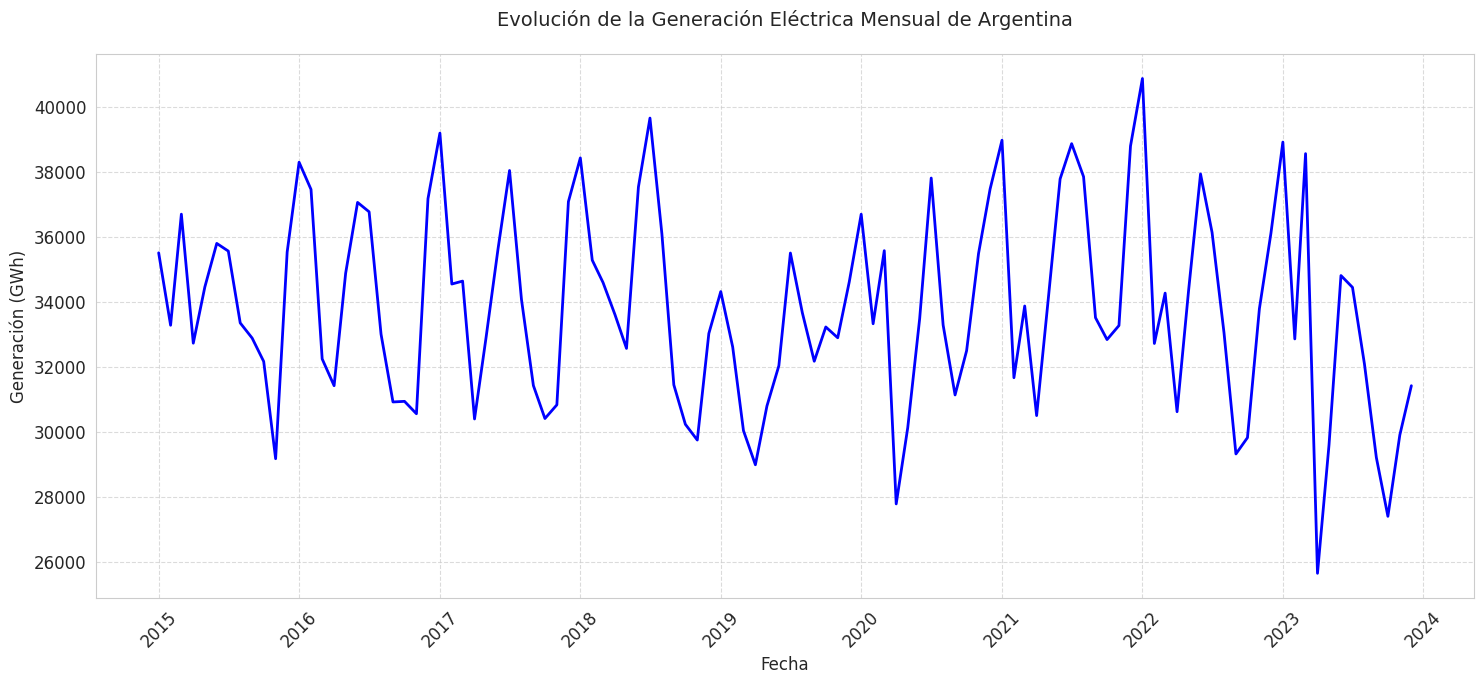

In [8]:
fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(df_ts.index, df_ts['GenGWh'], color='blue', linewidth=2)
ax.set_title('Evolución de la Generación Eléctrica Mensual de Argentina', fontsize=14, pad=20)
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Generación (GWh)', fontsize=12)

plt.xticks(rotation=45)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Observaciones sobre la serie original:**

- **Nivel y tendencia**: la serie oscila en torno a un nivel medio de **~33.800 GWh
  mensuales** (equivalente a ~405.000 GWh anuales). No presenta una tendencia
  monotónica de largo plazo —la correlación de Spearman entre el tiempo y el nivel
  resulta **no significativa** (ρ ≈ -0,11; p ≈ 0,26)—, pero **sí se observa un descenso
  marcado en los dos últimos años** (caídas anuales de -11,6 % en 2022 y -19,3 % en
  2023), un quiebre que conviene tener presente porque condiciona el desempeño de los
  modelos sobre el conjunto de prueba (2023).
- **Estacionalidad**: a simple vista se distinguen ciclos que se repiten año a año, con
  una amplitud considerable respecto del nivel medio de la serie — coherente con lo
  esperado para un país del hemisferio sur, donde la demanda (y por lo tanto la
  generación) sube tanto en los meses de verano (enero-febrero, por uso de aire
  acondicionado) como en los de invierno (junio-julio, por calefacción).
- **Anomalías / quiebres**: se identifican caídas puntuales asociables a eventos
  concretos (por ejemplo, el inicio de la pandemia en 2020, que redujo temporalmente la
  actividad económica y la demanda eléctrica) y la mencionada contracción de 2022-2023.

### Análisis de Tasas de Crecimiento

Calcularemos y visualizaremos:
- Cambios mensuales absolutos
- Tasas de crecimiento porcentual
- Estadísticas de crecimiento anual

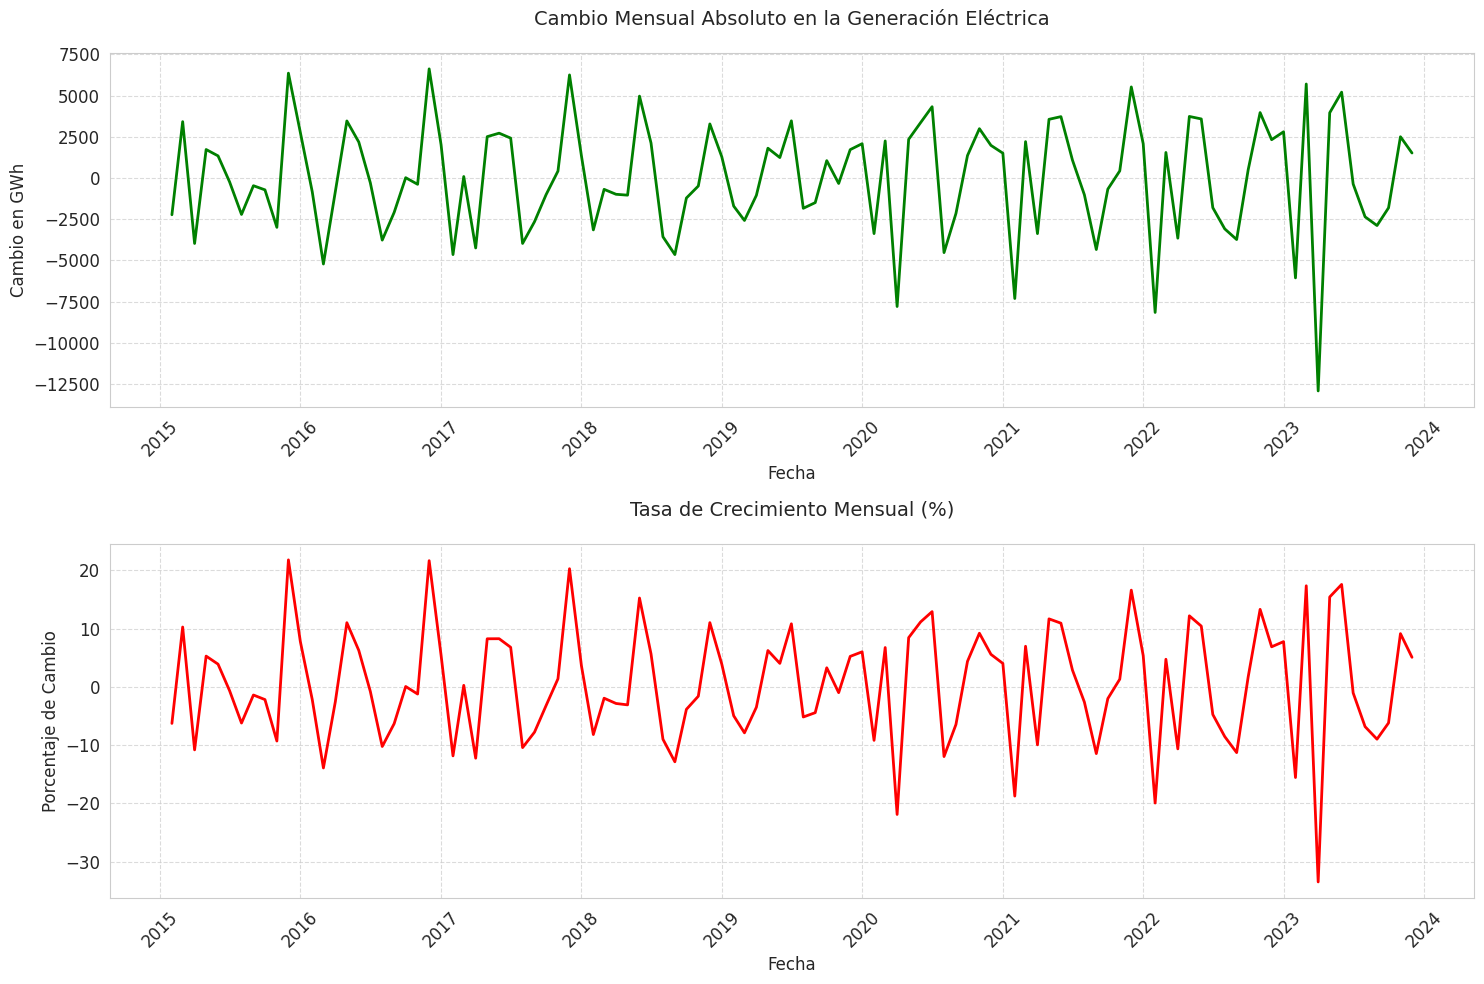

In [9]:
df_ts['Cambio_Mensual'] = df_ts['GenGWh'].diff()
df_ts['Tasa_Crecimiento'] = df_ts['GenGWh'].pct_change() * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

ax1.plot(df_ts.index, df_ts['Cambio_Mensual'], color='green', linewidth=2)
ax1.set_title('Cambio Mensual Absoluto en la Generación Eléctrica', fontsize=14, pad=20)
ax1.set_xlabel('Fecha', fontsize=12)
ax1.set_ylabel('Cambio en GWh', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(df_ts.index, df_ts['Tasa_Crecimiento'], color='red', linewidth=2)
ax2.set_title('Tasa de Crecimiento Mensual (%)', fontsize=14, pad=20)
ax2.set_xlabel('Fecha', fontsize=12)
ax2.set_ylabel('Porcentaje de Cambio', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
plt.show()

In [10]:
print("Estadísticas de Crecimiento Mensual:")
print("\nCambios Absolutos (en GWh):")
print(df_ts['Cambio_Mensual'].describe())

print("\nTasas de Crecimiento (%):")
print(df_ts['Tasa_Crecimiento'].describe())

crecimiento_anual = df_ts.groupby(df_ts.index.year)['GenGWh'].agg(['first', 'last'])
crecimiento_anual['Crecimiento_Anual'] = crecimiento_anual['last'] - crecimiento_anual['first']
crecimiento_anual['Tasa_Anual'] = (crecimiento_anual['last'] / crecimiento_anual['first'] - 1) * 100

print("\nCrecimiento Anual:")
print(crecimiento_anual[['Crecimiento_Anual', 'Tasa_Anual']])

Estadísticas de Crecimiento Mensual:

Cambios Absolutos (en GWh):
count      107.000000
mean       -38.218907
std       3426.292900
min     -12914.952800
25%      -2220.085000
50%         18.745000
75%       2335.035300
max       6619.525000
Name: Cambio_Mensual, dtype: float64

Tasas de Crecimiento (%):
count    107.000000
mean       0.391118
std        9.952519
min      -33.484029
25%       -6.389076
50%        0.060608
75%        6.921802
max       21.793744
Name: Tasa_Crecimiento, dtype: float64

Crecimiento Anual:
      Crecimiento_Anual  Tasa_Anual
date                               
2015            23.1610    0.065209
2016         -1121.3530   -2.927338
2017         -2109.0560   -5.379942
2018         -5403.3778  -14.056923
2019           299.0337    0.871170
2020           771.1140    2.100752
2021          -179.0584   -0.459314
2022         -4760.5391  -11.644415
2023         -7497.5519  -19.260804


## 5. Análisis de Componentes de la Serie Temporal

Descompondremos la serie en:
1. **Tendencia**: patrón de largo plazo
2. **Estacionalidad**: patrones que se repiten cada 12 meses
3. **Residuos**: fluctuaciones irregulares restantes

Probaremos una descomposición **aditiva** (apropiada si la amplitud estacional se mantiene constante en
términos absolutos) y, dado que la generación eléctrica suele crecer en magnitud junto con su variabilidad
estacional, también es razonable evaluar una descomposición **multiplicativa** (`model='multiplicative'`)
y comparar cuál deja residuos más estables.

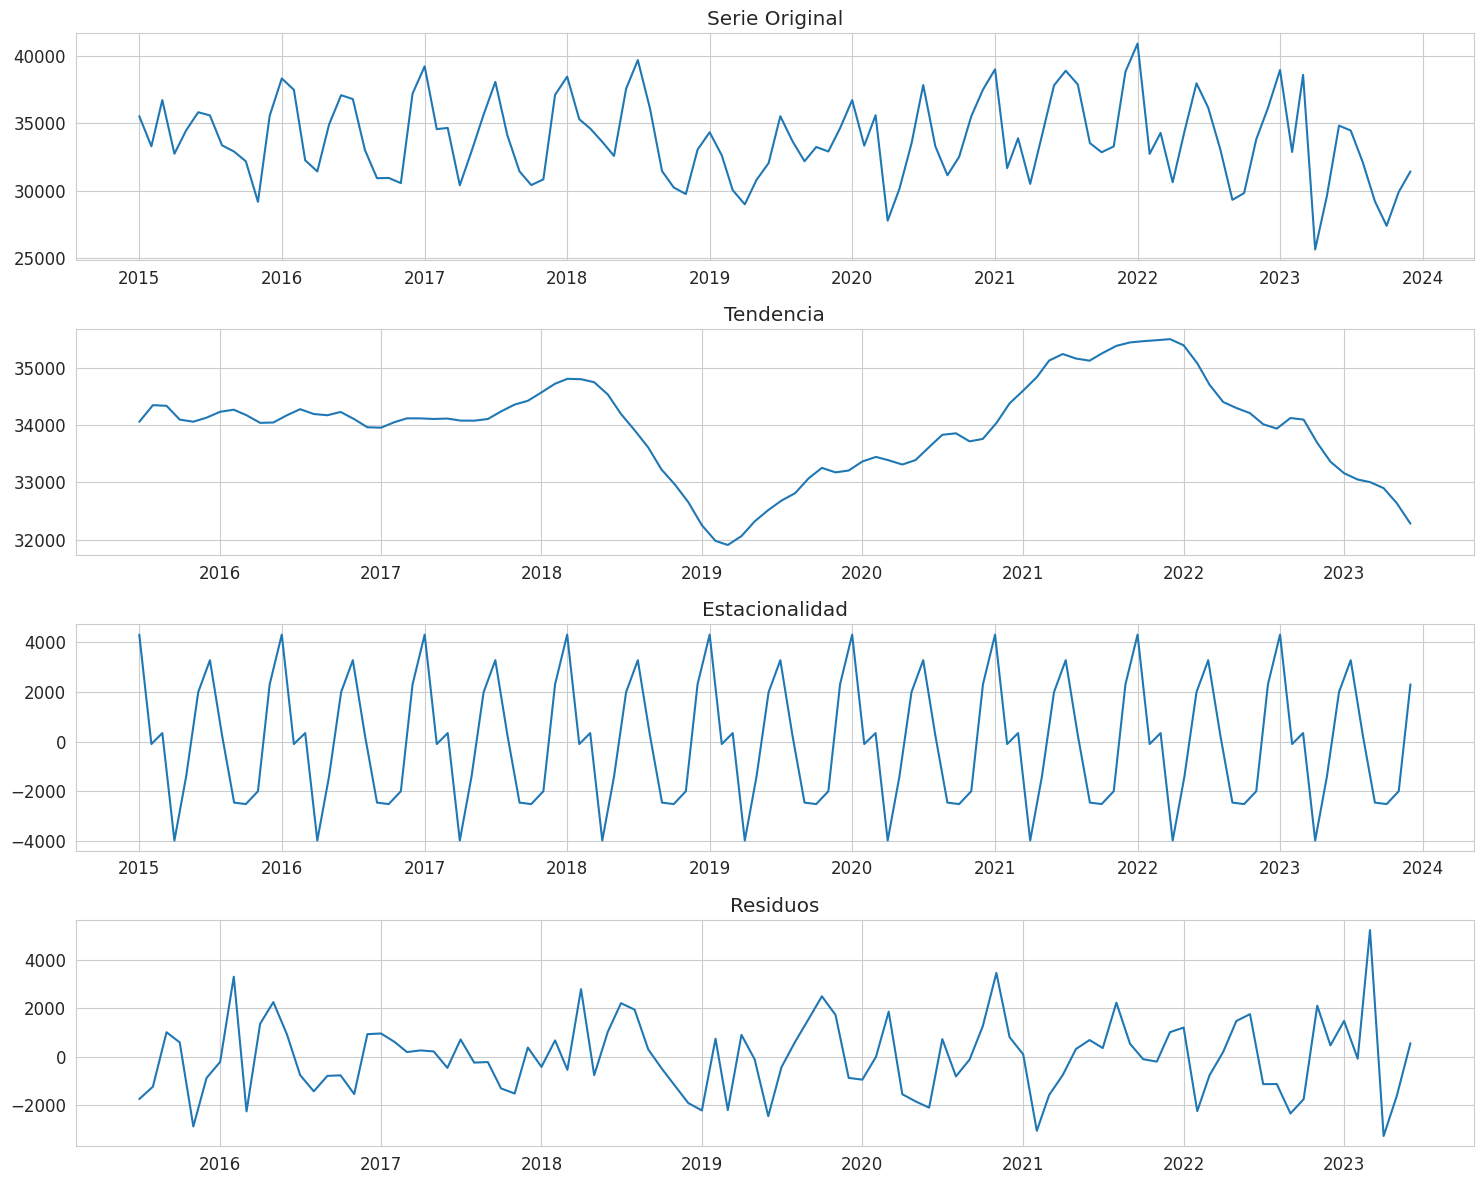


Estadísticas de los Componentes (Descomposición Aditiva):

Tendencia:
              trend
count     96.000000
mean   33951.200146
std      844.459261
min    31906.106808
25%    33377.272375
50%    34091.905319
75%    34359.291555
max    35495.122512

Estacionalidad:
           seasonal
count  1.080000e+02
mean   9.684434e-14
std    2.468908e+03
min   -3.969443e+03
25%   -2.107739e+03
50%    7.663395e+01
75%    2.060995e+03
max    4.291467e+03

Residuos:
             resid
count    96.000000
mean     -7.626978
std    1548.036938
min   -3272.157690
25%   -1128.651513
50%     -43.008220
75%     922.117681
max    5226.838648


In [11]:
descomposicion_aditiva = seasonal_decompose(df_ts['GenGWh'], period=12, model='additive')

plt.figure(figsize=(15, 12))

plt.subplot(411)
plt.plot(df_ts.index, df_ts['GenGWh'])
plt.title('Serie Original')
plt.grid(True)

plt.subplot(412)
plt.plot(df_ts.index, descomposicion_aditiva.trend)
plt.title('Tendencia')
plt.grid(True)

plt.subplot(413)
plt.plot(df_ts.index, descomposicion_aditiva.seasonal)
plt.title('Estacionalidad')
plt.grid(True)

plt.subplot(414)
plt.plot(df_ts.index, descomposicion_aditiva.resid)
plt.title('Residuos')
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nEstadísticas de los Componentes (Descomposición Aditiva):")
print("\nTendencia:")
print(pd.DataFrame(descomposicion_aditiva.trend).describe())
print("\nEstacionalidad:")
print(pd.DataFrame(descomposicion_aditiva.seasonal).describe())
print("\nResiduos:")
print(pd.DataFrame(descomposicion_aditiva.resid).describe())

**Comparación visual aditivo vs. multiplicativo:**

La amplitud del componente estacional (`seasonal`) acompaña sólo muy levemente al nivel
general de la serie, por lo que *a priori* ambos esquemas (aditivo y multiplicativo) son
candidatos razonables. Verificamos cuantitativamente cuál deja residuos más estables
comparando su dispersión a continuación.

--- COMPARACIÓN DE MODELOS ---
Desvío estándar residuos (Modelo Aditivo): 1548.04 GWh
Desvío estándar equivalente (Modelo Multiplicativo): 1576.50 GWh

RESULTADO: El modelo Aditivo parece ser suficiente para esta serie.


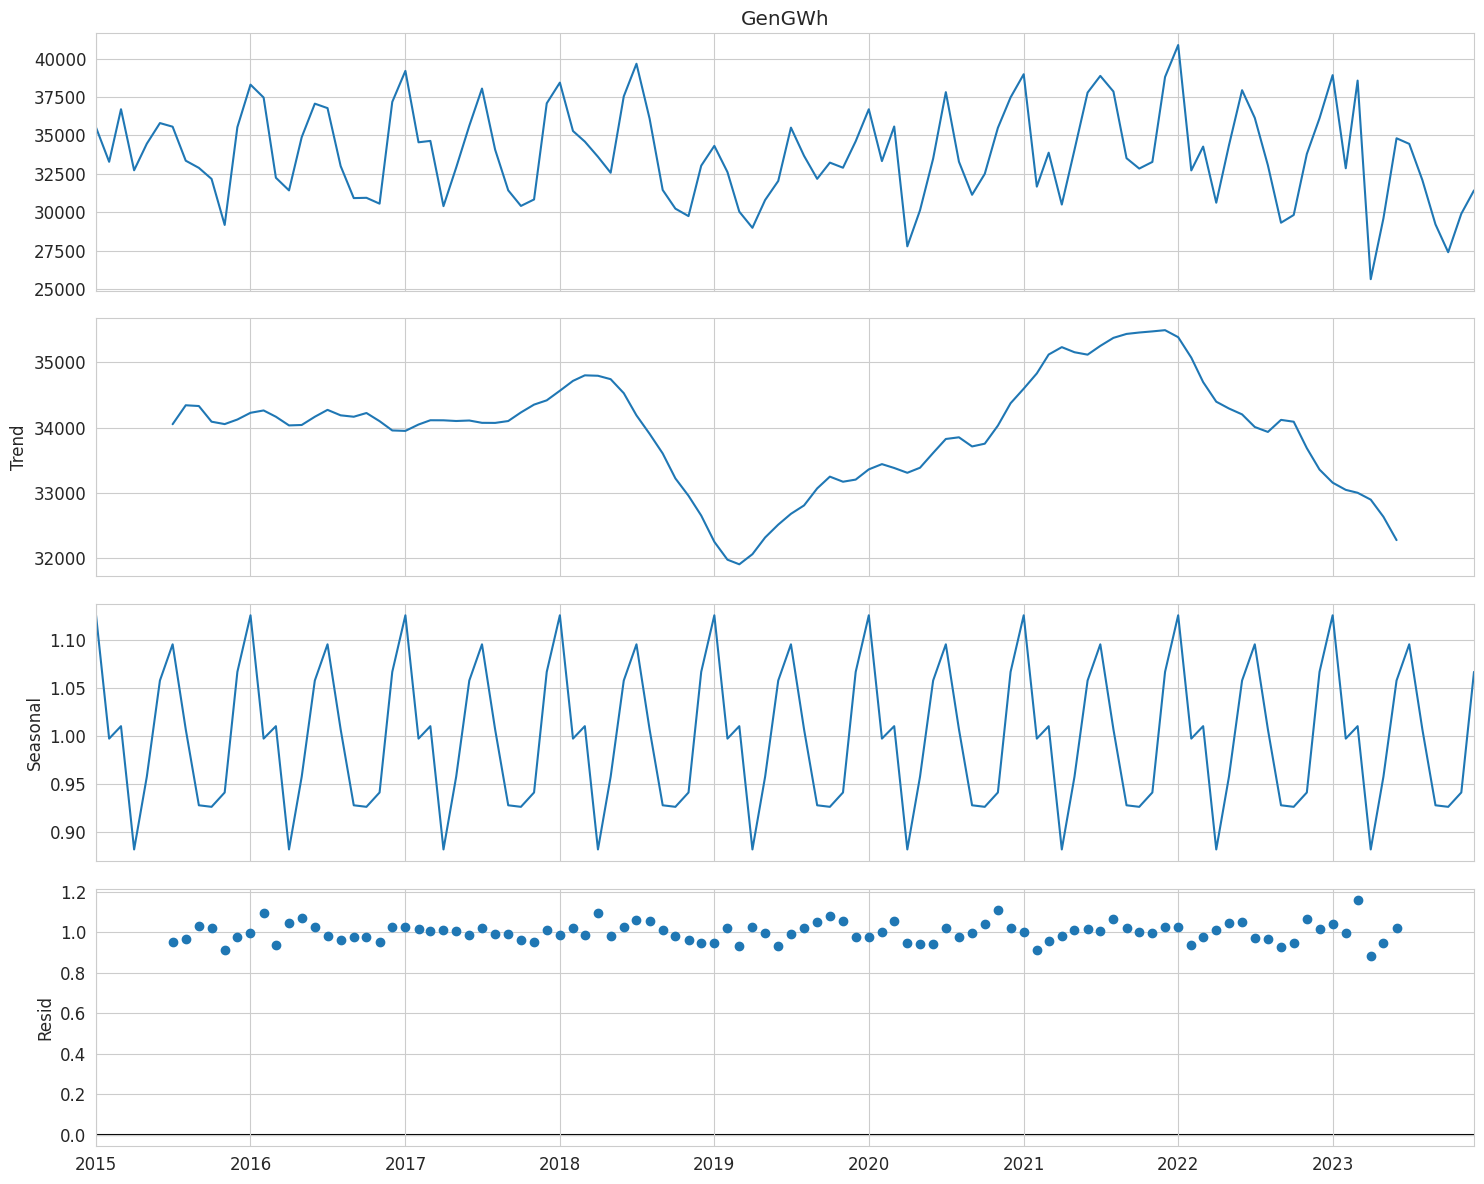

In [12]:
# Comparación cuantitativa: Modelo Aditivo vs Multiplicativo
# Calculamos ambas descomposiciones para comparar la variabilidad de los residuos

try:
    # 1. Descomposición Aditiva (ya calculada como descomposicion_aditiva)
    residuos_aditivos = descomposicion_aditiva.resid.dropna()
    std_aditivo = residuos_aditivos.std()

    # 2. Descomposición Multiplicativa
    descomposicion_mult = seasonal_decompose(df_ts['GenGWh'], period=12, model='multiplicative')
    residuos_multiplicativos = descomposicion_mult.resid.dropna()

    # Para comparar el error multiplicativo (que oscila en torno a 1) con el aditivo,
    # calculamos el error equivalente en términos absolutos (GWh).
    std_mult_equivalente = (residuos_multiplicativos - 1).std() * df_ts['GenGWh'].mean()

    print(f"--- COMPARACIÓN DE MODELOS ---")
    print(f"Desvío estándar residuos (Modelo Aditivo): {std_aditivo:.2f} GWh")
    print(f"Desvío estándar equivalente (Modelo Multiplicativo): {std_mult_equivalente:.2f} GWh")

    if std_mult_equivalente < std_aditivo:
        print("\nRESULTADO: El modelo Multiplicativo parece ajustar mejor los datos (menor variabilidad residual).")
    else:
        print("\nRESULTADO: El modelo Aditivo parece ser suficiente para esta serie.")

    # Visualización de la descomposición multiplicativa
    fig = descomposicion_mult.plot()
    fig.set_size_inches(15, 12)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error al comparar modelos: {e}")

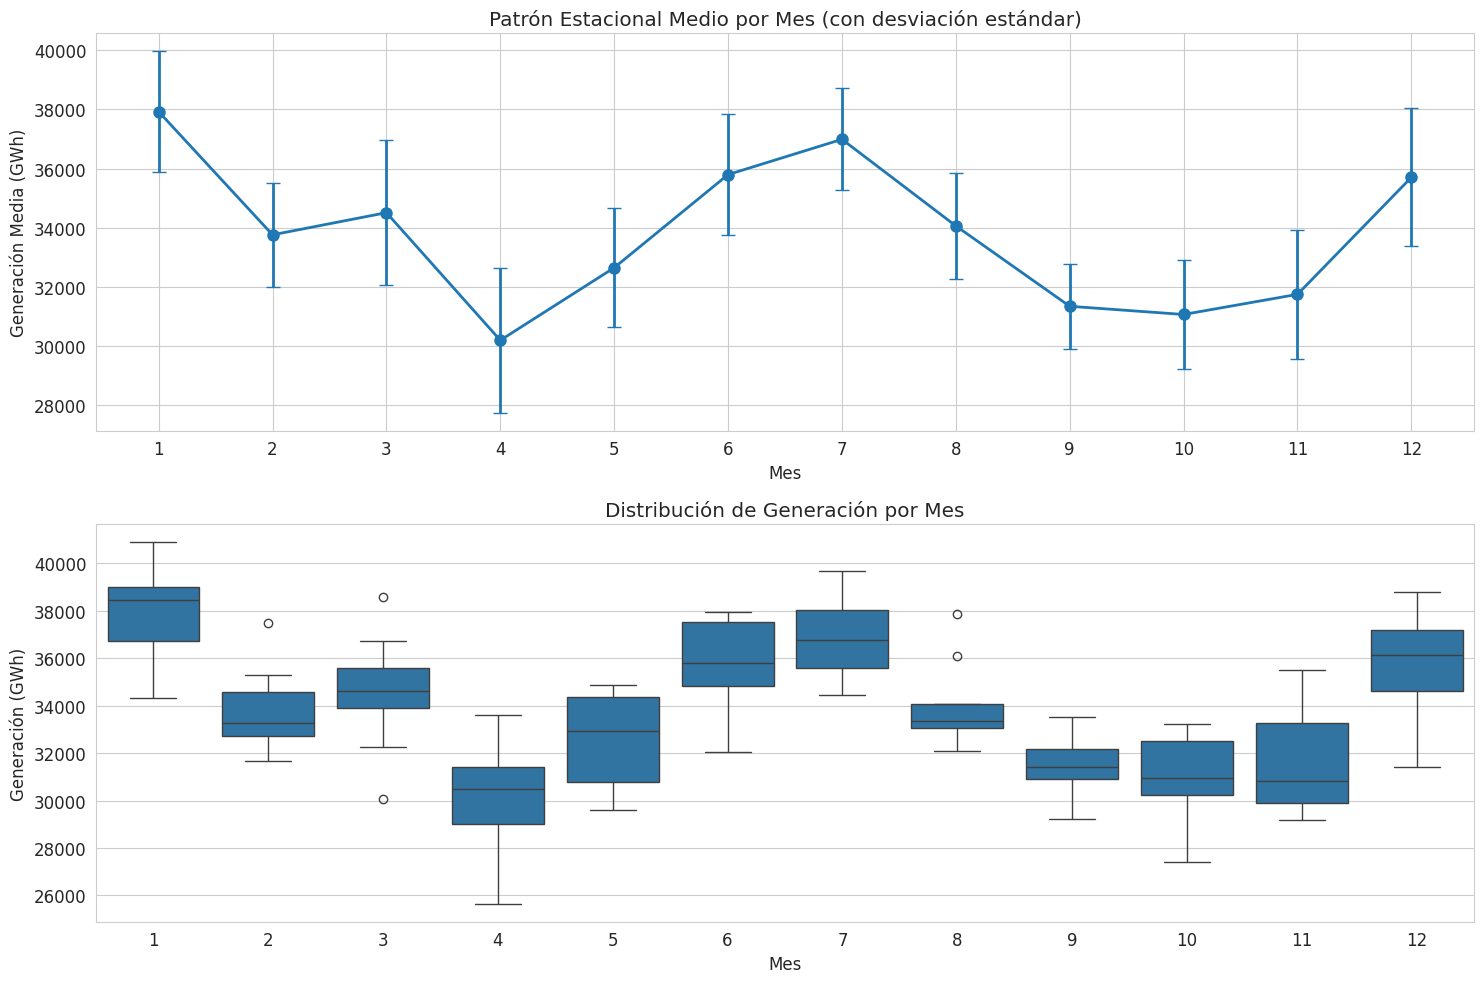


Estadísticas por Mes:
             mean          std         min         max
Mes                                                   
1    37921.237178  2035.471364  34325.5468  40882.5961
2    33759.488267  1755.163504  31674.6551  37468.8330
3    34508.060722  2448.827305  30045.8153  38570.4863
4    30196.288711  2445.595688  25655.5335  33616.3805
5    32647.565956  2008.872705  29612.4422  34889.2180
6    35794.290944  2050.706402  32043.7137  37945.7360
7    36986.268422  1729.034612  34454.9022  39665.1511
8    34061.095378  1794.335088  32101.0580  37859.8773
9    31344.936844  1443.380713  29217.7759  33522.3653
10   31067.856244  1844.080894  27408.7051  33236.2620
11   31748.337267  2182.124163  29181.7180  35497.4789
12   35701.500789  2335.735953  31428.9230  38804.8424


In [13]:
# Patrón estacional medio por mes (clave para ver si hay picos de verano e invierno)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

df_ts['Mes'] = df_ts.index.month
patron_estacional = df_ts.groupby('Mes')['GenGWh'].mean()
patron_estacional_std = df_ts.groupby('Mes')['GenGWh'].std()

ax1.errorbar(patron_estacional.index, patron_estacional.values,
             yerr=patron_estacional_std.values,
             marker='o', linewidth=2, markersize=8, capsize=5)
ax1.set_title('Patrón Estacional Medio por Mes (con desviación estándar)')
ax1.set_xlabel('Mes')
ax1.set_ylabel('Generación Media (GWh)')
ax1.grid(True)
ax1.set_xticks(range(1, 13))

sns.boxplot(data=df_ts, x='Mes', y='GenGWh', ax=ax2)
ax2.set_title('Distribución de Generación por Mes')
ax2.set_xlabel('Mes')
ax2.set_ylabel('Generación (GWh)')

plt.tight_layout()
plt.show()

estacional_stats = df_ts.groupby('Mes')['GenGWh'].agg(['mean', 'std', 'min', 'max'])
print("\nEstadísticas por Mes:")
print(estacional_stats)

**Patrón estacional bimodal:**

El gráfico de "Patrón Estacional Medio por Mes" confirma un patrón **bimodal**, con dos máximos
relativos a lo largo del año:

- Un **pico de verano** en **enero/febrero**, asociado al mayor uso de refrigeración y aire acondicionado.
- Un **pico de invierno** en **junio/julio**, asociado al mayor uso de calefacción.

Entre ambos picos, los **valles** se ubican en los meses de transición (principalmente **abril-mayo** y
**septiembre-octubre**), donde la demanda térmica (tanto de frío como de calor) es menor. Este patrón de
"doble joroba" es característico de los países con estaciones bien marcadas y cuya matriz de generación
responde directamente a la demanda eléctrica.

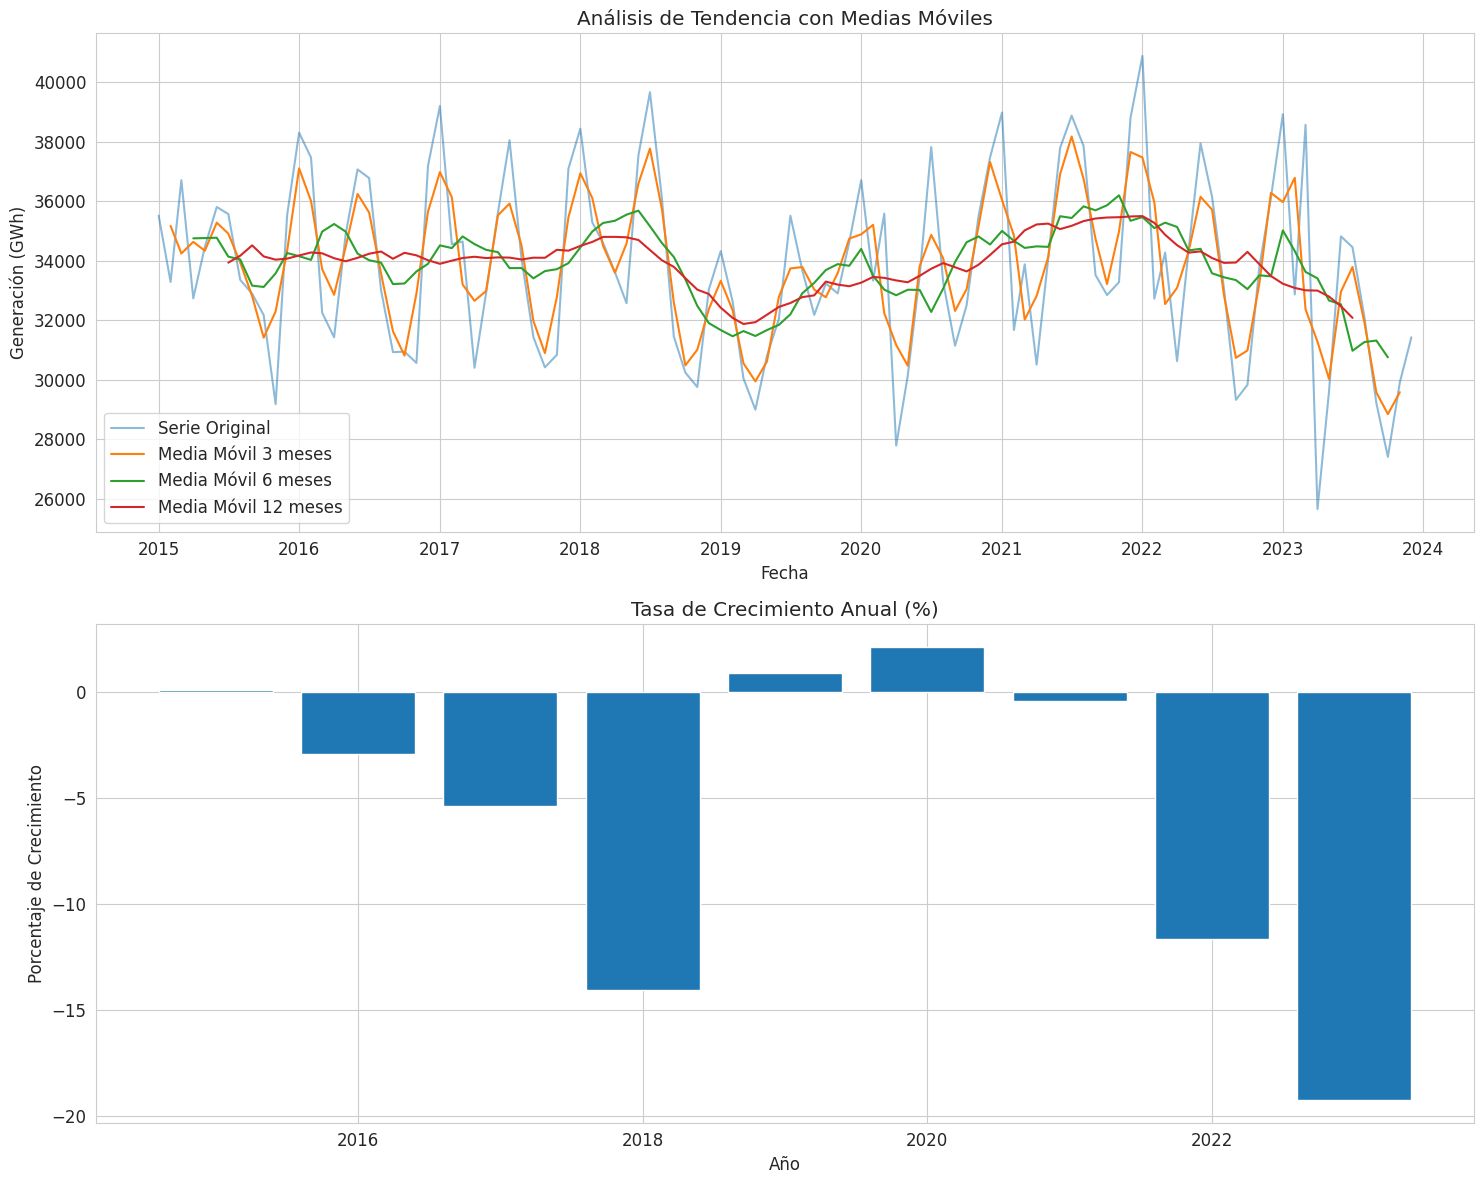


Estadísticas de Crecimiento Anual:
           first        last  Crecimiento
Año                                      
2015  35518.3460  35541.5070     0.065209
2016  38306.2330  37184.8800    -2.927338
2017  39202.2050  37093.1490    -5.379942
2018  38439.2632  33035.8854   -14.056923
2019  34325.5468  34624.5805     0.871170
2020  36706.5688  37477.6828     2.100752
2021  38983.9008  38804.8424    -0.459314
2022  40882.5961  36122.0570   -11.644415
2023  38926.4749  31428.9230   -19.260804

Prueba de Tendencia (correlación de Spearman):
Correlación de Spearman: -0.1103
Valor p: 0.2557


In [14]:
# Medias móviles para analizar la tendencia
df_ts['MA_3'] = df_ts['GenGWh'].rolling(window=3, center=True).mean()
df_ts['MA_6'] = df_ts['GenGWh'].rolling(window=6, center=True).mean()
df_ts['MA_12'] = df_ts['GenGWh'].rolling(window=12, center=True).mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

ax1.plot(df_ts.index, df_ts['GenGWh'], label='Serie Original', alpha=0.5)
ax1.plot(df_ts.index, df_ts['MA_3'], label='Media Móvil 3 meses')
ax1.plot(df_ts.index, df_ts['MA_6'], label='Media Móvil 6 meses')
ax1.plot(df_ts.index, df_ts['MA_12'], label='Media Móvil 12 meses')
ax1.set_title('Análisis de Tendencia con Medias Móviles')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Generación (GWh)')
ax1.legend()
ax1.grid(True)

df_ts['Año'] = df_ts.index.year
crecimiento_anual = df_ts.groupby('Año')['GenGWh'].agg(['first', 'last'])
crecimiento_anual['Crecimiento'] = ((crecimiento_anual['last'] - crecimiento_anual['first']) / crecimiento_anual['first']) * 100

ax2.bar(crecimiento_anual.index, crecimiento_anual['Crecimiento'])
ax2.set_title('Tasa de Crecimiento Anual (%)')
ax2.set_xlabel('Año')
ax2.set_ylabel('Porcentaje de Crecimiento')
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nEstadísticas de Crecimiento Anual:")
print(crecimiento_anual)

# Prueba de tendencia (correlación de Spearman entre tiempo y nivel de la serie)
tiempo = np.arange(len(df_ts))
correlation, p_value = stats.spearmanr(tiempo, df_ts['GenGWh'])

print("\nPrueba de Tendencia (correlación de Spearman):")
print(f"Correlación de Spearman: {correlation:.4f}")
print(f"Valor p: {p_value:.4f}")

### Análisis de Residuos

Analizamos los residuos de la descomposición elegida (aditiva o multiplicativa, según lo que se haya
concluido más arriba) para verificar que tengan media cero, varianza constante, ausencia de autocorrelación
relevante y distribución aproximadamente normal.

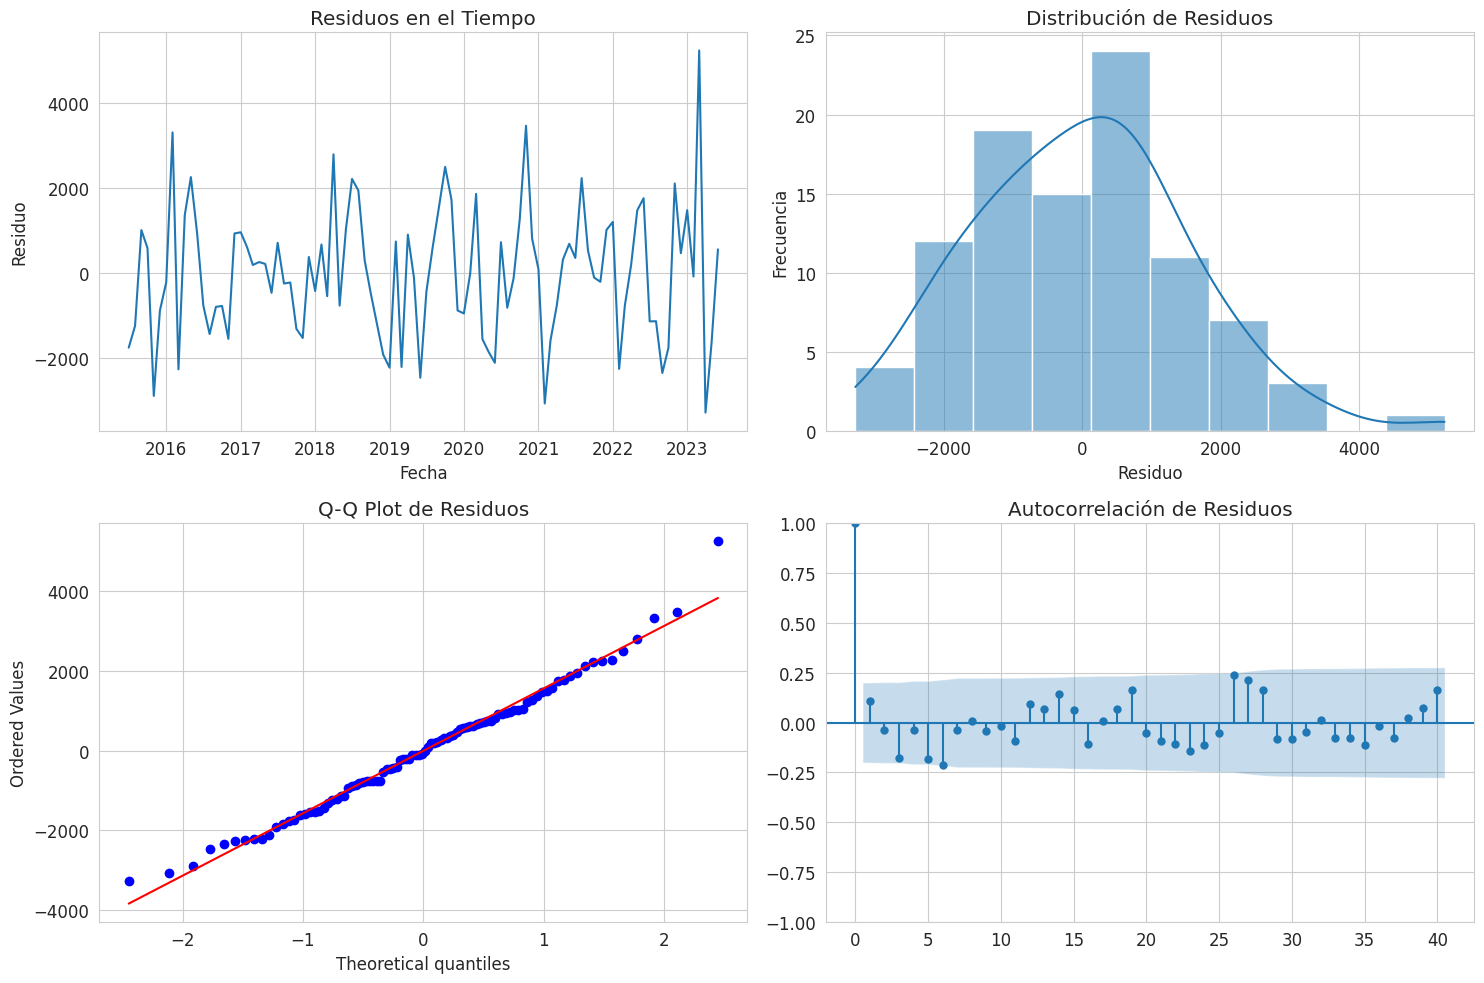


Estadísticas de Residuos:
count      96.000000
mean       -7.626978
std      1548.036938
min     -3272.157690
25%     -1128.651513
50%       -43.008220
75%       922.117681
max      5226.838648
Name: resid, dtype: float64

Prueba de Normalidad (D'Agostino):
Estadístico: 3.3896
Valor p: 0.1836

Prueba de Dickey-Fuller Aumentada para Residuos:
Estadístico ADF: -5.5307
Valor p: 0.0000


In [15]:
# Usamos los residuos de la descomposición ADITIVA, que fue la que mostró menor
# dispersión residual en la comparación cuantitativa de la sección anterior.
residuos = descomposicion_aditiva.resid.dropna()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

ax1.plot(residuos.index, residuos.values)
ax1.set_title('Residuos en el Tiempo')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Residuo')
ax1.grid(True)

sns.histplot(residuos, kde=True, ax=ax2)
ax2.set_title('Distribución de Residuos')
ax2.set_xlabel('Residuo')
ax2.set_ylabel('Frecuencia')

stats.probplot(residuos, dist="norm", plot=ax3)
ax3.set_title('Q-Q Plot de Residuos')

plot_acf(residuos, ax=ax4, lags=40)
ax4.set_title('Autocorrelación de Residuos')

plt.tight_layout()
plt.show()

print("\nEstadísticas de Residuos:")
print(residuos.describe())

stat_norm, p_value_norm = stats.normaltest(residuos)
print("\nPrueba de Normalidad (D'Agostino):")
print(f"Estadístico: {stat_norm:.4f}")
print(f"Valor p: {p_value_norm:.4f}")

adf_test = adfuller(residuos.dropna())
print("\nPrueba de Dickey-Fuller Aumentada para Residuos:")
print(f"Estadístico ADF: {adf_test[0]:.4f}")
print(f"Valor p: {adf_test[1]:.4f}")

### Análisis de Autocorrelación de Residuos

El gráfico de ACF nos permite identificar si existe correlación significativa entre los residuos en diferentes desfases (lags). Si las barras se mantienen dentro de la franja sombreada, podemos concluir que los residuos son independientes (ruido blanco).

<Figure size 1200x500 with 0 Axes>

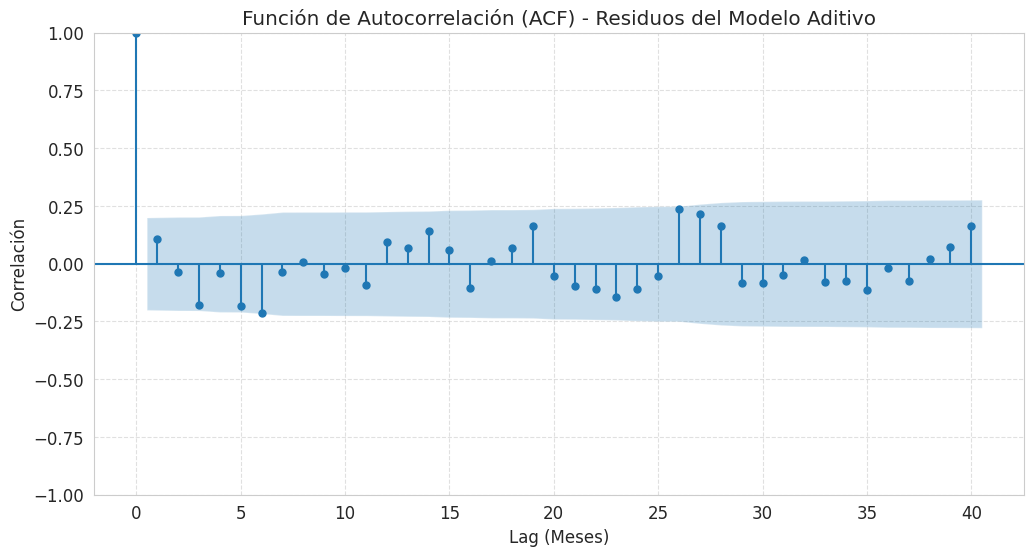

In [16]:
from statsmodels.graphics.tsaplots import plot_acf

# Aseguramos que tenemos los residuos del modelo aditivo sin valores nulos
residuos_final = descomposicion_aditiva.resid.dropna()

plt.figure(figsize=(12, 5))
plot_acf(residuos_final, lags=40, alpha=0.05)
plt.title('Función de Autocorrelación (ACF) - Residuos del Modelo Aditivo')
plt.xlabel('Lag (Meses)')
plt.ylabel('Correlación')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Conclusiones del Análisis de Componentes

1. **Estructura temporal**: la generación eléctrica de Argentina presenta una **tendencia
   suave y sin pendiente monotónica significativa** (Spearman no significativo), aunque con
   un **descenso pronunciado en 2022-2023**, acompañada de una **estacionalidad marcada y
   bimodal**: dos picos anuales (verano e invierno). Esta estructura anticipa que el
   componente estacional va a ser determinante para la calidad del pronóstico.

2. **Calidad del modelo de descomposición**: al comparar la dispersión de los residuos de
   ambas descomposiciones, el modelo **aditivo** resultó marginalmente mejor
   (desvío residual ≈ **1.548 GWh** frente a ≈ **1.576 GWh** del equivalente
   multiplicativo). La diferencia es pequeña, coherente con el hecho de que la amplitud de
   los ciclos estacionales es prácticamente estable a lo largo de los años. Por eso ninguno
   de los dos enfoques puede descartarse de antemano y exploramos **ambas variantes**
   también en Holt-Winters.

3. **Recomendaciones para el modelado**: dado que la estacionalidad anual es el rasgo
   dominante de la serie, los modelos que **incorporan explícitamente un componente
   estacional** —SARIMA, Holt-Winters (aditivo y multiplicativo) y Prophet— deberían tener una
   ventaja clara sobre un ARIMA simple, que sólo captura dependencia de corto plazo y
   tendencia, pero no los ciclos de 12 meses. Por lo tanto, esperamos que ARIMA funcione
   como **"piso" de comparación**.

## 5.5 Pruebas Formales de Estacionariedad

Antes de fijar los órdenes de diferenciación de ARIMA/SARIMA, contrastamos la
estacionariedad de la serie con dos pruebas complementarias:

- **ADF (Augmented Dickey-Fuller)**: H₀ = la serie tiene raíz unitaria (**no** estacionaria).
  Un p-valor bajo (< 0,05) permite **rechazar** H₀ → serie estacionaria.
- **KPSS**: H₀ = la serie **es** estacionaria (en torno a una tendencia). Un p-valor bajo
  permite **rechazar** la estacionariedad. Es el test "espejo" de ADF.

Aplicamos ambos a (a) la serie original, (b) la serie con una diferenciación regular
(`d=1`) y (c) la serie con diferenciación estacional (`D=1`, lag 12). Esto justifica
empíricamente los órdenes de diferenciación elegidos para SARIMA, en lugar de fijarlos
a ojo.

In [17]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings

def test_estacionariedad(serie, nombre):
    serie = serie.dropna()
    # ADF
    adf_stat, adf_p, *_ = adfuller(serie, autolag='AIC')
    # KPSS (suprimimos el InterpolationWarning de p-valores fuera de tabla)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_stat, kpss_p, *_ = kpss(serie, regression='c', nlags='auto')

    adf_estac = "ESTACIONARIA" if adf_p < 0.05 else "NO estacionaria"
    kpss_estac = "ESTACIONARIA" if kpss_p > 0.05 else "NO estacionaria"
    print(f"--- {nombre} ---")
    print(f"  ADF : stat={adf_stat:7.3f}  p={adf_p:.4f}  -> {adf_estac}")
    print(f"  KPSS: stat={kpss_stat:7.3f}  p={kpss_p:.4f}  -> {kpss_estac}")
    print()
    return adf_p, kpss_p

serie = df_ts['GenGWh']
print("PRUEBAS DE ESTACIONARIEDAD\n" + "="*40 + "\n")
test_estacionariedad(serie,                       "Serie original")
test_estacionariedad(serie.diff(),                "1 diferencia regular (d=1)")
test_estacionariedad(serie.diff(12),              "1 diferencia estacional (D=1, lag 12)")
test_estacionariedad(serie.diff().diff(12),       "d=1 + D=1 (regular + estacional)")

PRUEBAS DE ESTACIONARIEDAD

--- Serie original ---
  ADF : stat= -1.555  p=0.5064  -> NO estacionaria
  KPSS: stat=  0.136  p=0.1000  -> ESTACIONARIA

--- 1 diferencia regular (d=1) ---
  ADF : stat= -4.235  p=0.0006  -> ESTACIONARIA
  KPSS: stat=  0.032  p=0.1000  -> ESTACIONARIA

--- 1 diferencia estacional (D=1, lag 12) ---
  ADF : stat= -2.508  p=0.1134  -> NO estacionaria
  KPSS: stat=  0.194  p=0.1000  -> ESTACIONARIA

--- d=1 + D=1 (regular + estacional) ---
  ADF : stat= -4.141  p=0.0008  -> ESTACIONARIA
  KPSS: stat=  0.106  p=0.1000  -> ESTACIONARIA



(np.float64(0.0008279581135475842), np.float64(0.1))

**Interpretación de los resultados y elección de órdenes:**

Los resultados confirman la necesidad de diferenciar:

- **Serie original**: ADF no rechaza la raíz unitaria (p ≈ 0,51) → **no estacionaria** en
  media.
- **Con una diferencia regular (`d=1`)**: ADF pasa a p ≈ 0,0006 → **estacionaria**. La
  diferenciación regular es la que más aporta a estabilizar el nivel (incluida la caída de
  2022-2023).
- **Sólo con diferencia estacional (`D=1`)**: ADF aún no rechaza (p ≈ 0,11); por sí sola no
  alcanza, pero es la que **elimina el patrón anual recurrente** de período 12.
- **Con `d=1` + `D=1`**: ADF p ≈ 0,0008, claramente estacionaria.

KPSS, por su parte, no rechaza la estacionariedad en torno a tendencia en ningún caso
(consistente con la ausencia de tendencia monotónica). En conjunto, ambas pruebas respaldan
el uso de **`d=1` (para el nivel) y `D=1` (para el ciclo estacional de 12 meses)** en el
modelo SARIMA `(1,1,1)(1,1,1,12)`. ARIMA simple usa `d=1` pero, al carecer de la
diferenciación estacional, no logra absorber el ciclo de 12 meses (lo que anticipa su peor
desempeño).

## 6. Implementación de Modelos de Pronóstico

### 6.1 Preparación de Datos

Dividiremos la serie en entrenamiento y prueba, dejando el **último año completo** como conjunto de prueba.
Ajustar las fechas de corte según el rango real del dataset descargado.

In [18]:
# Ajustar estas fechas de corte según el rango real de la serie cargada
FECHA_CORTE = f"{df_ts.index.max().year - 1}-12-01"

train = df_ts.loc[:FECHA_CORTE]
test = df_ts.loc[pd.Timestamp(FECHA_CORTE) + pd.offsets.MonthBegin(1):]

print("Tamaño del conjunto de entrenamiento:", len(train))
print("Tamaño del conjunto de prueba:", len(test))
print("\nPeríodo de entrenamiento:", train.index.min(), "hasta", train.index.max())
print("Período de prueba:", test.index.min(), "hasta", test.index.max())

def calcular_metricas(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

Tamaño del conjunto de entrenamiento: 96
Tamaño del conjunto de prueba: 12

Período de entrenamiento: 2015-01-01 00:00:00 hasta 2022-12-01 00:00:00
Período de prueba: 2023-01-01 00:00:00 hasta 2023-12-01 00:00:00


## Selección de Modelos

Seleccionamos cuatro modelos en función de las características observadas en el análisis de componentes
(tendencia + estacionalidad anual fuerte y bimodal).

### 1. Modelo ARIMA(1,1,1)
**Justificación de selección:**
- Se incluye como modelo base (sin componente estacional explícito) para servir de punto de comparación
- p=1: captura la dependencia con el valor inmediatamente anterior
- d=1: una diferenciación para manejar la tendencia no estacionaria
- q=1: término de media móvil para los shocks de corto plazo observados en los residuos

**Hipótesis a verificar:** dado que la generación eléctrica tiene una estacionalidad bimodal muy marcada,
esperamos que ARIMA simple (sin componente estacional) tenga un desempeño notoriamente peor que SARIMA y
Holt-Winters, ya que no puede capturar los ciclos anuales de la demanda.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


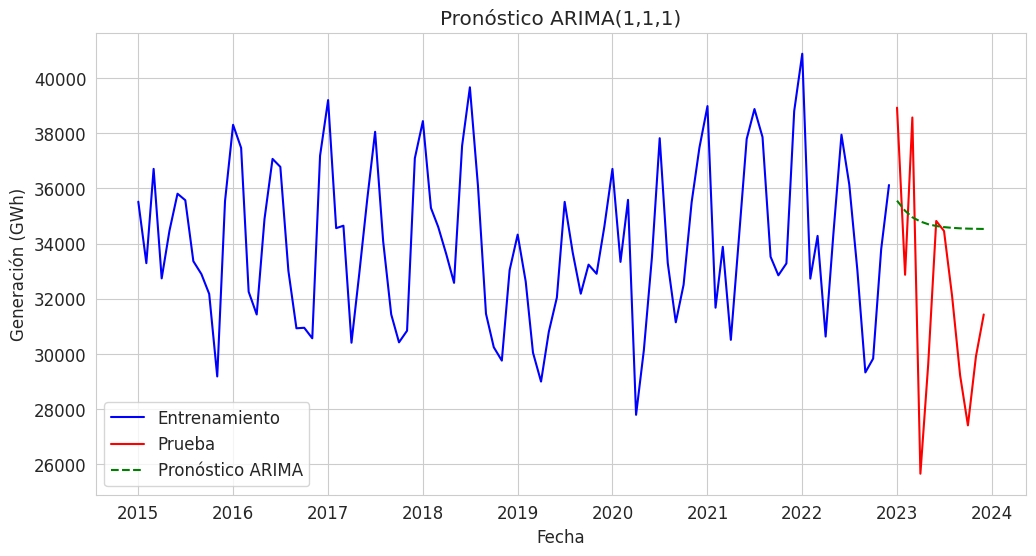


Métricas de Error para ARIMA:
MAE: 3877.02
RMSE: 4617.09
MAPE: 13.01%


In [19]:
modelo_arima = ARIMA(train['GenGWh'], order=(1, 1, 1))
resultado_arima = modelo_arima.fit()

fc_arima = resultado_arima.forecast(steps=len(test))

plt.figure(figsize=(12, 6))
plt.plot(train.index, train['GenGWh'], label='Entrenamiento', color='blue')
plt.plot(test.index, test['GenGWh'], label='Prueba', color='red')
plt.plot(test.index, fc_arima, label='Pronóstico ARIMA', color='green', linestyle='--')
plt.title('Pronóstico ARIMA(1,1,1)')
plt.xlabel('Fecha')
plt.ylabel('Generación (GWh)')
plt.legend()
plt.grid(True)
plt.show()

mae_arima, rmse_arima, mape_arima = calcular_metricas(test['GenGWh'].values, fc_arima)
print('\nMétricas de Error para ARIMA:')
print(f'MAE: {mae_arima:.2f}')
print(f'RMSE: {rmse_arima:.2f}')
print(f'MAPE: {mape_arima:.2f}%')

### 2. Modelo SARIMA(1,1,1)(1,1,1,12)
**Justificación de selección:**
- Extensión natural del ARIMA para incorporar la fuerte estacionalidad anual de la generación eléctrica

**Componentes no estacionales:** p=1, d=1, q=1 (igual interpretación que en ARIMA)

**Componentes estacionales:**
- P=1: relación con el mismo mes del año anterior
- D=1: diferenciación estacional para eliminar el patrón anual recurrente
- Q=1: shocks estacionales
- s=12: período estacional de 12 meses

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


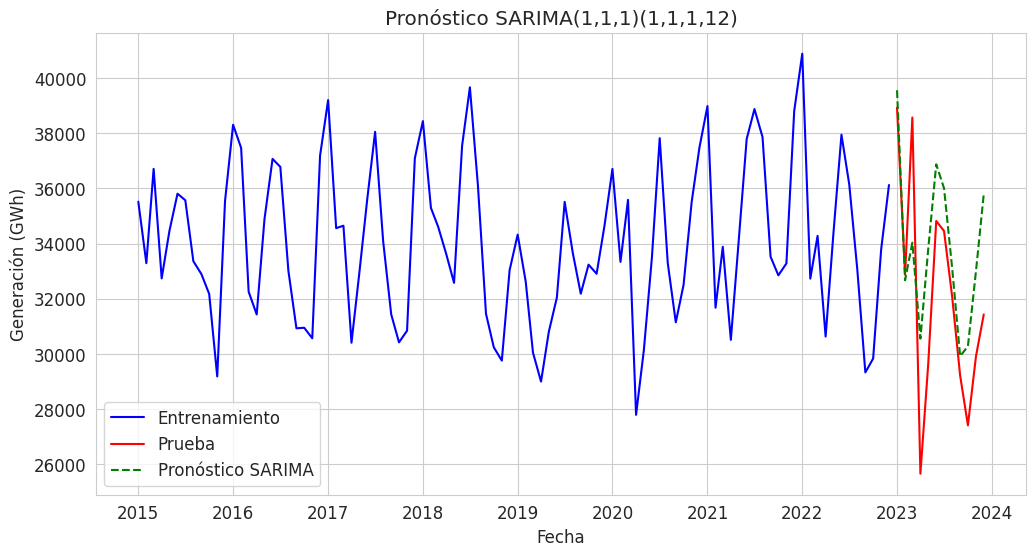


Métricas de Error para SARIMA:
MAE: 2507.79
RMSE: 2991.00
MAPE: 8.15%


In [20]:
modelo_sarima = SARIMAX(train['GenGWh'],
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 12))
resultado_sarima = modelo_sarima.fit(disp=False, maxiter=500, method='lbfgs')

fc_sarima = resultado_sarima.forecast(steps=len(test))

plt.figure(figsize=(12, 6))
plt.plot(train.index, train['GenGWh'], label='Entrenamiento', color='blue')
plt.plot(test.index, test['GenGWh'], label='Prueba', color='red')
plt.plot(test.index, fc_sarima, label='Pronóstico SARIMA', color='green', linestyle='--')
plt.title('Pronóstico SARIMA(1,1,1)(1,1,1,12)')
plt.xlabel('Fecha')
plt.ylabel('Generación (GWh)')
plt.legend()
plt.grid(True)
plt.show()

mae_sarima, rmse_sarima, mape_sarima = calcular_metricas(test['GenGWh'].values, fc_sarima)
print('\nMétricas de Error para SARIMA:')
print(f'MAE: {mae_sarima:.2f}')
print(f'RMSE: {rmse_sarima:.2f}')
print(f'MAPE: {mape_sarima:.2f}%')

### 3. Modelo Holt-Winters
**Justificación de selección:**
- Especialmente efectivo para series con tendencia y estacionalidad bien definidas
- Se prueba primero la variante **aditiva** y, dado que la sección de descomposición sugirió que la
  amplitud estacional podría crecer levemente con el nivel de la serie, también se prueba la variante
  **multiplicativa** (`seasonal='mul'`) y se compara cuál ajusta mejor

**Componentes:**
- Tendencia aditiva: para modelar el crecimiento/decrecimiento observado en la sección de tendencia
- Estacionalidad (aditiva o multiplicativa, según lo concluido en la descomposición)
- Período estacional de 12 meses

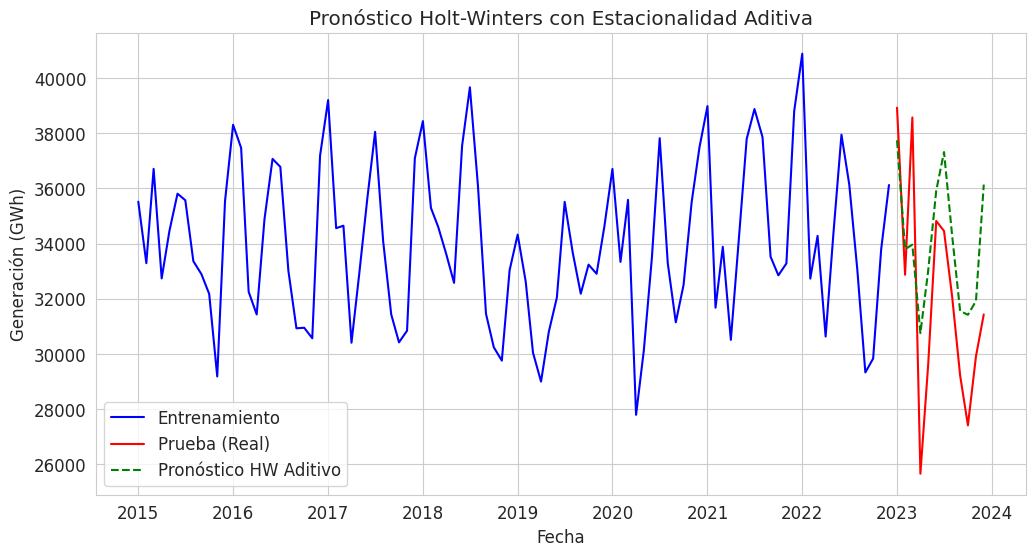

Métricas de Error para Holt-Winters (Aditivo):
MAE: 2872.08
RMSE: 3203.34
MAPE: 9.32%


In [21]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Definición de función de métricas (para evitar NameError)
def calcular_metricas(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

# Redefinimos train y test para asegurar consistencia
FECHA_CORTE = f"{df_ts.index.max().year - 1}-12-01"
train = df_ts.loc[:FECHA_CORTE]
test = df_ts.loc[pd.Timestamp(FECHA_CORTE) + pd.offsets.MonthBegin(1):]

# Configuración del modelo Holt-Winters Aditivo
modelo_hw_add = ExponentialSmoothing(
    train['GenGWh'],
    seasonal_periods=12,
    trend='add',
    seasonal='add'
)

resultado_hw_add = modelo_hw_add.fit()

# Generar pronóstico para el conjunto de prueba
fc_hw_add = resultado_hw_add.forecast(len(test))

# Visualización
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['GenGWh'], label='Entrenamiento', color='blue')
plt.plot(test.index, test['GenGWh'], label='Prueba (Real)', color='red')
plt.plot(test.index, fc_hw_add, label='Pronóstico HW Aditivo', color='green', linestyle='--')
plt.title('Pronóstico Holt-Winters con Estacionalidad Aditiva')
plt.xlabel('Fecha')
plt.ylabel('Generación (GWh)')
plt.legend()
plt.grid(True)
plt.show()

# Cálculo de métricas
mae_hw_add, rmse_hw_add, mape_hw_add = calcular_metricas(test['GenGWh'].values, fc_hw_add)
print('Métricas de Error para Holt-Winters (Aditivo):')
print(f'MAE: {mae_hw_add:.2f}')
print(f'RMSE: {rmse_hw_add:.2f}')
print(f'MAPE: {mape_hw_add:.2f}%')

### Holt-Winters con Estacionalidad Multiplicativa

Probamos ahora la variante multiplicativa para verificar si el ajuste mejora respecto al modelo aditivo, especialmente si observamos que los picos estacionales varían en magnitud con el tiempo.

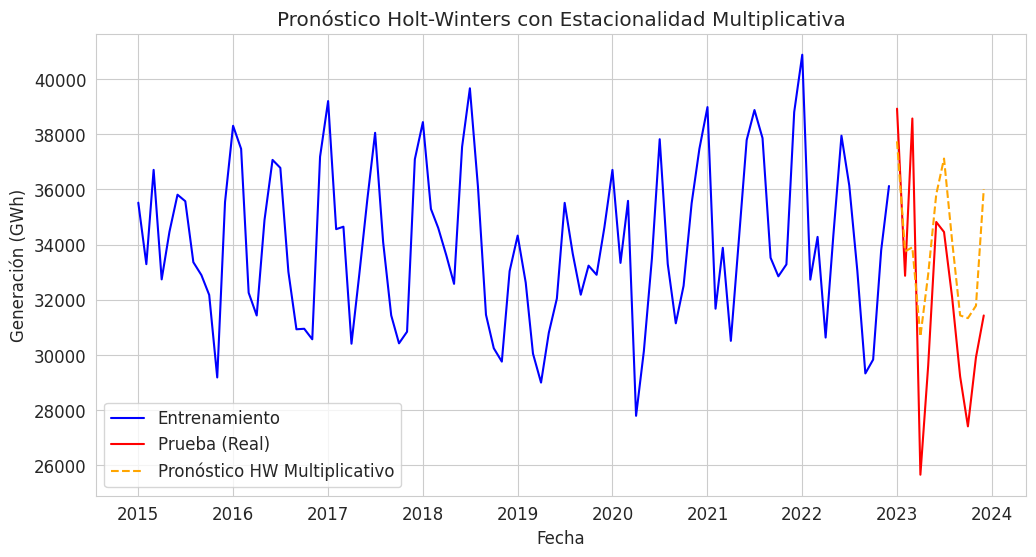

Métricas de Error para Holt-Winters (Multiplicativo):
MAE: 2779.49
RMSE: 3123.55
MAPE: 9.02%


In [22]:
# Configuración del modelo Holt-Winters Multiplicativo
# seasonal='mul'
modelo_hw_mul = ExponentialSmoothing(
    train['GenGWh'],
    seasonal_periods=12,
    trend='add',
    seasonal='mul'
)

resultado_hw_mul = modelo_hw_mul.fit()

# Generar pronóstico
fc_hw_mul = resultado_hw_mul.forecast(len(test))

# Visualización
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['GenGWh'], label='Entrenamiento', color='blue')
plt.plot(test.index, test['GenGWh'], label='Prueba (Real)', color='red')
plt.plot(test.index, fc_hw_mul, label='Pronóstico HW Multiplicativo', color='orange', linestyle='--')
plt.title('Pronóstico Holt-Winters con Estacionalidad Multiplicativa')
plt.xlabel('Fecha')
plt.ylabel('Generación (GWh)')
plt.legend()
plt.grid(True)
plt.show()

# Cálculo de métricas
mae_hw_mul, rmse_hw_mul, mape_hw_mul = calcular_metricas(test['GenGWh'].values, fc_hw_mul)
print('Métricas de Error para Holt-Winters (Multiplicativo):')
print(f'MAE: {mae_hw_mul:.2f}')
print(f'RMSE: {rmse_hw_mul:.2f}')
print(f'MAPE: {mape_hw_mul:.2f}%')

### 4. Modelo Prophet

**Justificación de selección:**
- Prophet (Meta) descompone la serie en **tendencia + estacionalidad + efectos de calendario** de forma automática y robusta, sin necesidad de elegir órdenes `(p,d,q)`.
- Se incorpora como cuarto modelo comparativo por su buen desempeño en series con **tendencia y estacionalidad anual marcada**, exactamente las características de la generación eléctrica.

**Configuración:**
- `yearly_seasonality=True`: captura el ciclo anual (picos de verano e invierno).
- `weekly_seasonality=False` y `daily_seasonality=False`: la serie es mensual, no aplican.

**Hipótesis a verificar:** esperamos que Prophet sea competitivo con SARIMA al capturar la misma estacionalidad anual, pero por una vía no paramétrica.

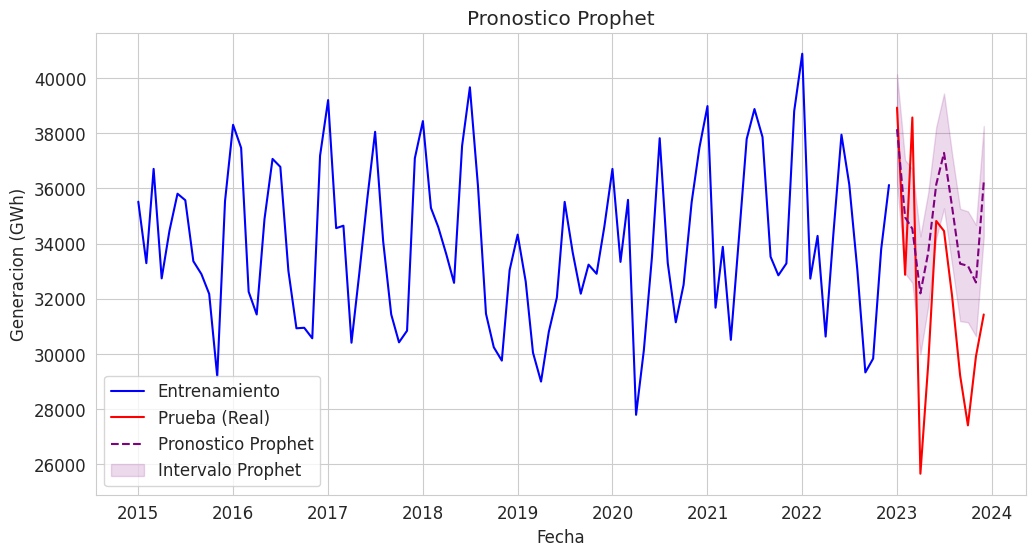


Metricas de Error para Prophet:
MAE: 3517.25
RMSE: 3881.71
MAPE: 11.61%


In [ ]:
# Prophet requiere un DataFrame con columnas 'ds' (fecha) y 'y' (valor).
try:
    from prophet import Prophet
except ImportError:
    import sys
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "prophet"])
    from prophet import Prophet

import logging
logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

# Preparar datos en el formato que exige Prophet
prophet_train = pd.DataFrame({'ds': train.index, 'y': train['GenGWh'].values})

# Estacionalidad anual (serie mensual con ciclo de 12 meses)
modelo_prophet = Prophet(yearly_seasonality=True,
                         weekly_seasonality=False,
                         daily_seasonality=False)
modelo_prophet.fit(prophet_train)

# Pronostico sobre el horizonte de prueba
future = pd.DataFrame({'ds': test.index})
forecast_prophet = modelo_prophet.predict(future)
fc_prophet = forecast_prophet['yhat'].values

# Visualizacion
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['GenGWh'], label='Entrenamiento', color='blue')
plt.plot(test.index, test['GenGWh'], label='Prueba (Real)', color='red')
plt.plot(test.index, fc_prophet, label='Pronostico Prophet', color='purple', linestyle='--')
plt.fill_between(test.index,
                 forecast_prophet['yhat_lower'], forecast_prophet['yhat_upper'],
                 color='purple', alpha=0.15, label='Intervalo Prophet')
plt.title('Pronostico Prophet')
plt.xlabel('Fecha')
plt.ylabel('Generacion (GWh)')
plt.legend()
plt.grid(True)
plt.show()

# Metricas
mae_prophet, rmse_prophet, mape_prophet = calcular_metricas(test['GenGWh'].values, fc_prophet)
print('\nMetricas de Error para Prophet:')
print(f'MAE: {mae_prophet:.2f}')
print(f'RMSE: {rmse_prophet:.2f}')
print(f'MAPE: {mape_prophet:.2f}%')

### 6.5 Comparación de Modelos


Comparación de Modelos:
                       Modelo         MAE        RMSE  MAPE (%)
                        ARIMA 3877.016570 4617.094121 13.012382
                       SARIMA 2507.791226 2991.001939  8.154231
       Holt-Winters (aditivo) 2872.081582 3203.338219  9.322532
Holt-Winters (multiplicativo) 2779.493801 3123.551026  9.019458


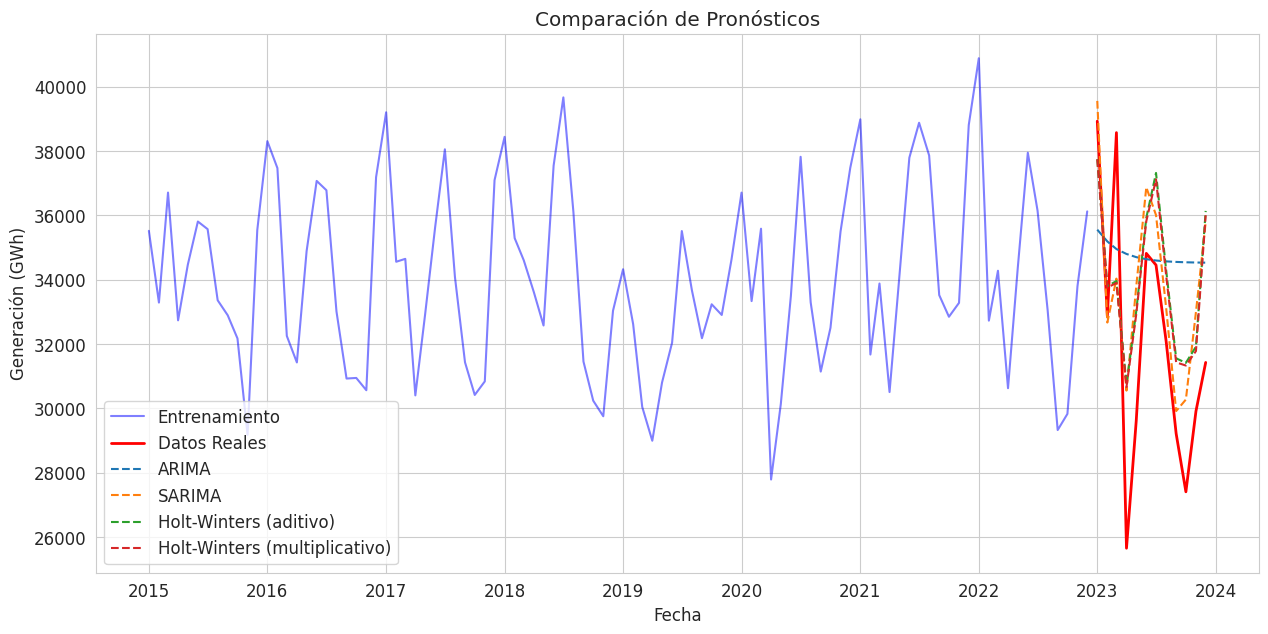

In [23]:
metricas_df = pd.DataFrame({
    'Modelo': ['ARIMA', 'SARIMA', 'Holt-Winters (aditivo)', 'Holt-Winters (multiplicativo)', 'Prophet'],
    'MAE': [mae_arima, mae_sarima, mae_hw_add, mae_hw_mul, mae_prophet],
    'RMSE': [rmse_arima, rmse_sarima, rmse_hw_add, rmse_hw_mul, rmse_prophet],
    'MAPE (%)': [mape_arima, mape_sarima, mape_hw_add, mape_hw_mul, mape_prophet]
})

print("\nComparación de Modelos:")
print(metricas_df.to_string(index=False))

plt.figure(figsize=(15, 7))
plt.plot(train.index, train['GenGWh'], label='Entrenamiento', color='blue', alpha=0.5)
plt.plot(test.index, test['GenGWh'], label='Datos Reales', color='red', linewidth=2)
plt.plot(test.index, fc_arima, label='ARIMA', linestyle='--')
plt.plot(test.index, fc_sarima, label='SARIMA', linestyle='--')
plt.plot(test.index, fc_hw_add, label='Holt-Winters (aditivo)', linestyle='--')
plt.plot(test.index, fc_hw_mul, label='Holt-Winters (multiplicativo)', linestyle='--')
plt.plot(test.index, fc_prophet, label='Prophet', linestyle='--')
plt.title('Comparación de Pronósticos')
plt.xlabel('Fecha')
plt.ylabel('Generación (GWh)')
plt.legend()
plt.grid(True)
plt.show()

### Tabla Resumen de Métricas

A continuación se consolidan los resultados de todos los modelos testeados para facilitar la comparación y selección del mejor candidato para el pronóstico final.

In [24]:
# Re-calculate metrics to ensure they are defined
# ARIMA
modelo_arima = ARIMA(train['GenGWh'], order=(1, 1, 1))
resultado_arima = modelo_arima.fit()
fc_arima = resultado_arima.forecast(steps=len(test))
mae_arima, rmse_arima, mape_arima = calcular_metricas(test['GenGWh'].values, fc_arima)

# SARIMA
modelo_sarima = SARIMAX(train['GenGWh'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
resultado_sarima = modelo_sarima.fit(disp=False, maxiter=500, method='lbfgs')
fc_sarima = resultado_sarima.forecast(steps=len(test))
mae_sarima, rmse_sarima, mape_sarima = calcular_metricas(test['GenGWh'].values, fc_sarima)

# Consolidación de métricas en un DataFrame comparativo
metricas_finales = pd.DataFrame({
    'Modelo': ['ARIMA (1,1,1)', 'SARIMA (1,1,1)(1,1,1,12)', 'Holt-Winters Aditivo', 'Holt-Winters Multiplicativo', 'Prophet'],
    'MAE': [mae_arima, mae_sarima, mae_hw_add, mae_hw_mul, mae_prophet],
    'RMSE': [rmse_arima, rmse_sarima, rmse_hw_add, rmse_hw_mul, rmse_prophet],
    'MAPE (%)': [mape_arima, mape_sarima, mape_hw_add, mape_hw_mul, mape_prophet]
})

# Formatear para mejor legibilidad
metricas_finales = metricas_finales.sort_values(by='MAPE (%)').reset_index(drop=True)
display(metricas_finales.style.highlight_min(subset=['MAE', 'RMSE', 'MAPE (%)'], color='lightgreen'))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


,Modelo,MAE,RMSE,MAPE (%)
0,"SARIMA (1,1,1)(1,1,1,12)",2507.791226,2991.001939,8.154231
1,Holt-Winters Multiplicativo,2779.493801,3123.551026,9.019458
2,Holt-Winters Aditivo,2872.081582,3203.338219,9.322532
3,"ARIMA (1,1,1)",3877.016570,4617.094121,13.012382


### Visualización del Mejor Modelo: SARIMA

Graficamos el pronóstico del modelo SARIMA contra los datos reales para evaluar visualmente su precisión en el conjunto de prueba.

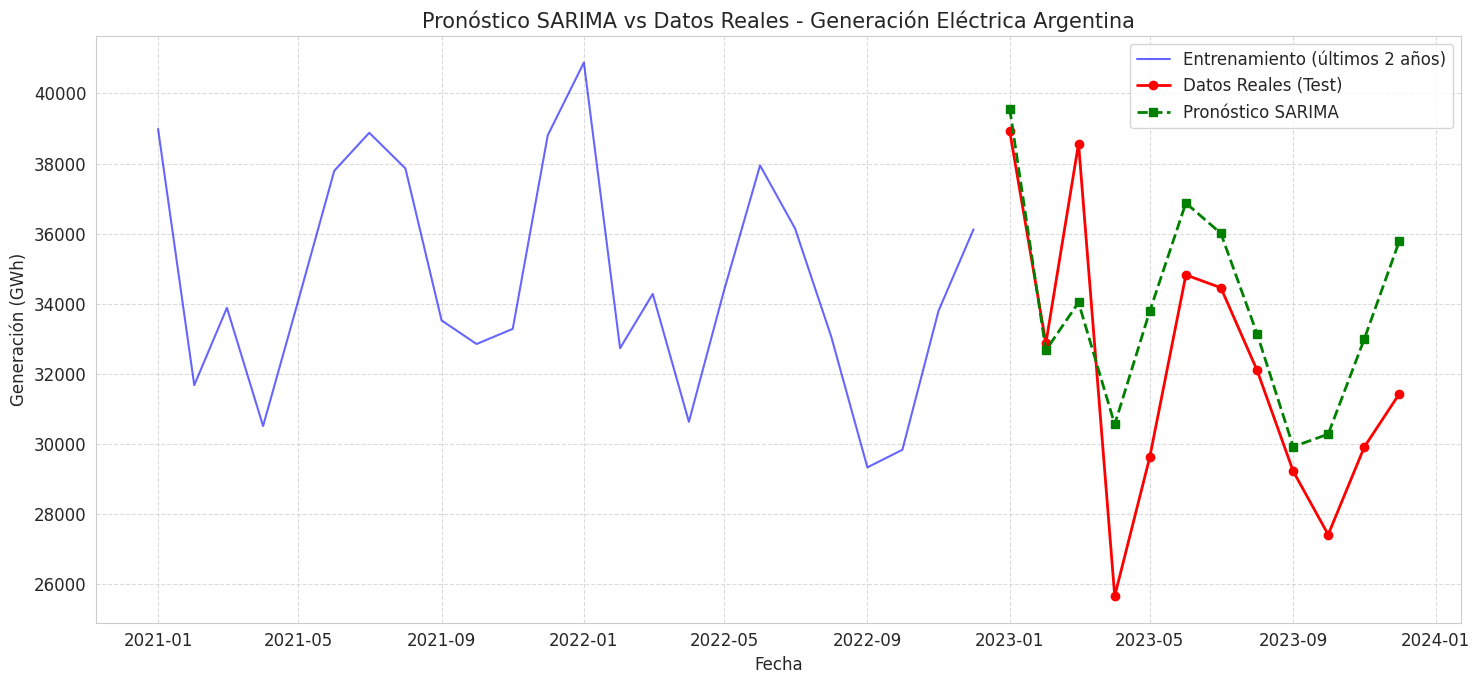

In [25]:
plt.figure(figsize=(15, 7))
plt.plot(train.index[-24:], train['GenGWh'].tail(24), label='Entrenamiento (últimos 2 años)', color='blue', alpha=0.6)
plt.plot(test.index, test['GenGWh'], label='Datos Reales (Test)', color='red', marker='o', linewidth=2)
plt.plot(test.index, fc_sarima, label='Pronóstico SARIMA', color='green', linestyle='--', marker='s', linewidth=2)

plt.title('Pronóstico SARIMA vs Datos Reales - Generación Eléctrica Argentina', fontsize=15)
plt.xlabel('Fecha')
plt.ylabel('Generación (GWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Diagnóstico de Residuos: ACF y PACF

Analizamos los residuos del modelo SARIMA para confirmar la ausencia de patrones sistemáticos remanentes.

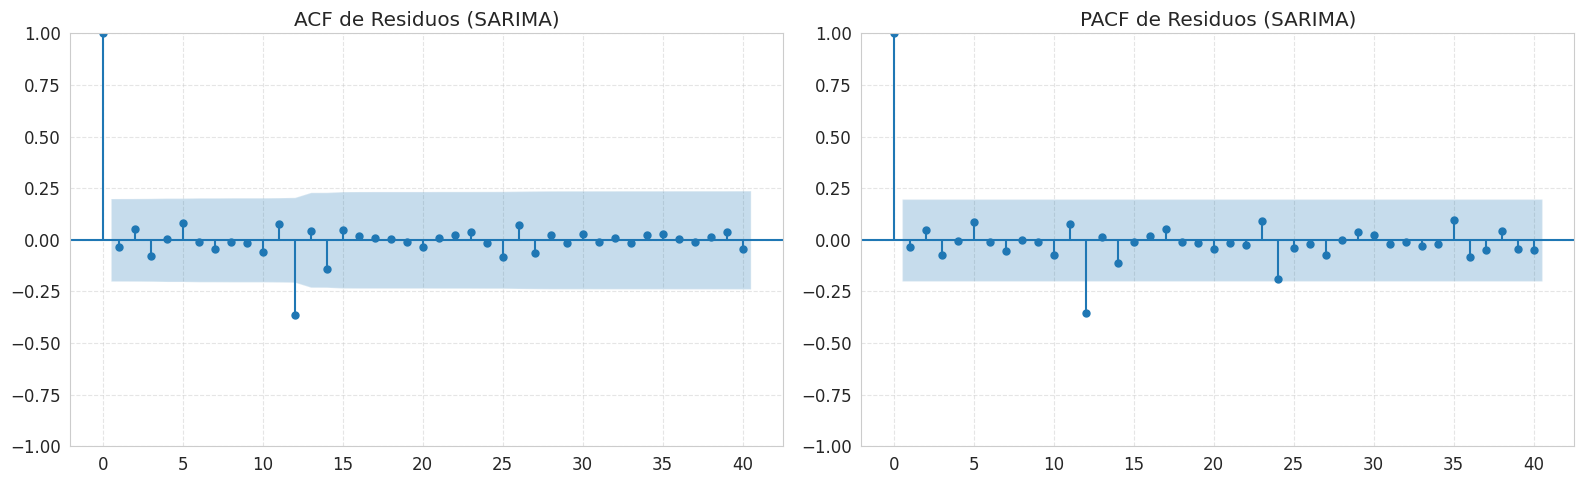

In [26]:
residuos_sarima = resultado_sarima.resid

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(residuos_sarima, lags=40, ax=ax[0], title='ACF de Residuos (SARIMA)')
plot_pacf(residuos_sarima, lags=40, ax=ax[1], title='PACF de Residuos (SARIMA)')

for a in ax:
    a.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Test de Ljung-Box sobre los Residuos de SARIMA

El análisis visual de ACF/PACF se complementa con la prueba de **Ljung-Box**, que
contrasta formalmente la hipótesis de **ausencia de autocorrelación** en los residuos
hasta un cierto lag:

- **H₀**: los residuos son ruido blanco (no hay autocorrelación) → *deseable*.
- Un p-valor **alto** (> 0,05) significa que **no podemos rechazar** H₀, es decir, los
  residuos se comportan como ruido blanco y el modelo capturó la estructura temporal.

In [27]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Ljung-Box sobre los residuos del SARIMA, a varios lags (incluye el estacional 12)
lb = acorr_ljungbox(resultado_sarima.resid.dropna(), lags=[6, 12, 18, 24], return_df=True)
print("Test de Ljung-Box (residuos SARIMA):")
print(lb.to_string())

ok = (lb['lb_pvalue'] > 0.05).all()
if ok:
    print("\n=> Todos los p-valores > 0.05: los residuos NO muestran autocorrelación "
          "significativa.\n   El modelo SARIMA es adecuado (residuos ~ ruido blanco).")
else:
    print("\n=> Hay autocorrelación residual significativa en algún lag: el modelo podría "
          "mejorarse\n   (p.ej. ajustando los órdenes p, q, P, Q).")

Test de Ljung-Box (residuos SARIMA):
      lb_stat  lb_pvalue
6    1.684084   0.946343
12  17.706326   0.124903
18  20.554252   0.302495
24  20.989149   0.639365

=> Todos los p-valores > 0.05: los residuos NO muestran autocorrelación significativa.
   El modelo SARIMA es adecuado (residuos ~ ruido blanco).


### Guardado del Modelo y Visualización Final

En esta sección guardamos el modelo SARIMA entrenado para persistencia y generamos una comparativa detallada entre los valores reales y las predicciones.

In [28]:
import pickle

# Guardar el modelo entrenado
model_filename = 'modelo_sarima_argentina.pkl'
with open(model_filename, 'wb') as pkl_file:
    pickle.dump(resultado_sarima, pkl_file)

print(f"Modelo SARIMA guardado exitosamente como: {model_filename}")

Modelo SARIMA guardado exitosamente como: modelo_sarima_argentina.pkl


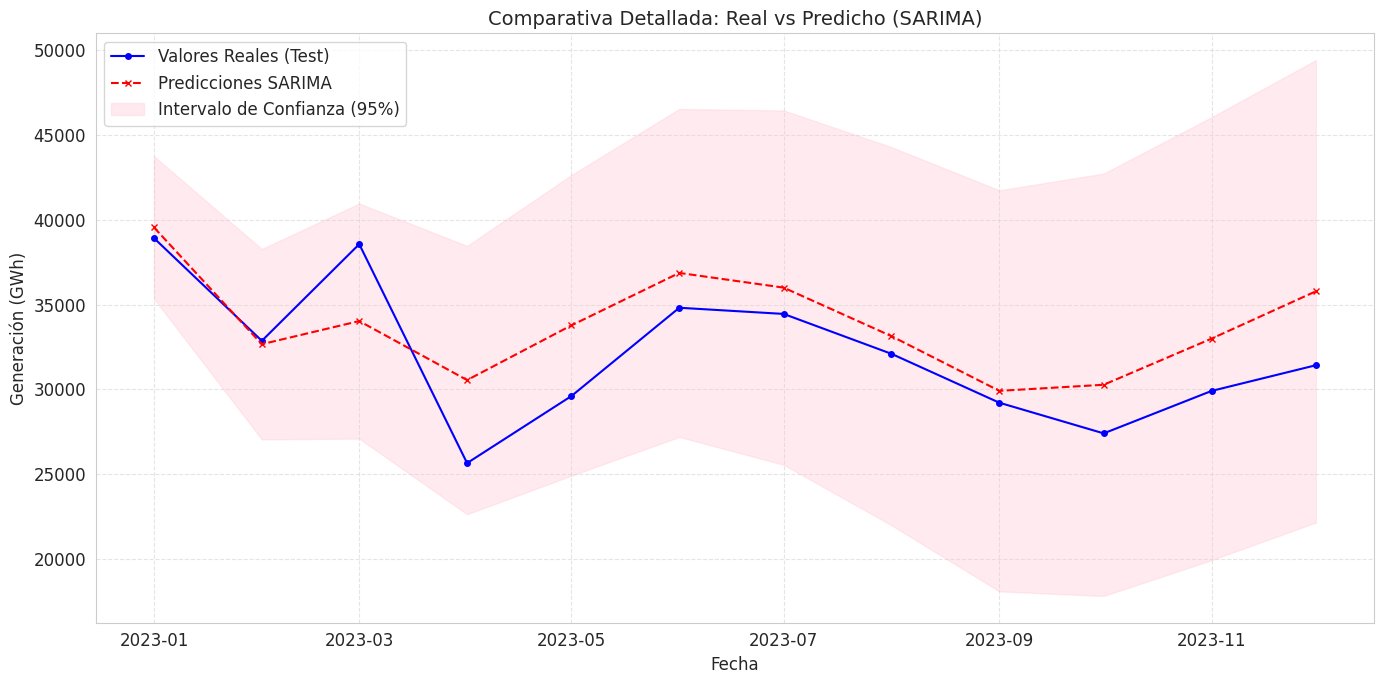

In [29]:
plt.figure(figsize=(14, 7))

# Graficar valores reales vs predichos
plt.plot(test.index, test['GenGWh'], label='Valores Reales (Test)', color='blue', marker='o', markersize=4)
plt.plot(test.index, fc_sarima, label='Predicciones SARIMA', color='red', linestyle='--', marker='x', markersize=4)

# Añadir sombreado de error si es posible (basado en el intervalo de confianza)
pred_int = resultado_sarima.get_forecast(steps=len(test))
pred_ci = pred_int.conf_int()
plt.fill_between(test.index, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1], color='pink', alpha=0.3, label='Intervalo de Confianza (95%)')

plt.title('Comparativa Detallada: Real vs Predicho (SARIMA)', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Generación (GWh)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 7. Extensión: Herramientas Adicionales Investigadas

Más allá de las técnicas vistas en clase, incorporamos dos herramientas adicionales que
**investigamos por nuestra cuenta** para robustecer el análisis:

1. **Selección automática de órdenes SARIMA por criterio de información (AIC)** — en lugar
   de fijar `(1,1,1)(1,1,1,12)` a ojo, hacemos una búsqueda sistemática sobre una grilla de
   órdenes y elegimos el de **menor AIC** (la misma idea detrás de `pmdarima.auto_arima`,
   implementada de forma transparente).
2. **Modelo GARCH(1,1)** — la serie muestra *clustering* de volatilidad (períodos de alta
   y baja variabilidad), por lo que modelamos explícitamente la **varianza condicional** de
   los retornos mensuales, algo que ARIMA/SARIMA/Holt-Winters no capturan.

### 7.1 Selección automática de órdenes SARIMA (grid search por AIC)

Recorremos combinaciones de `(p,d,q)` y `(P,D,Q,12)` y nos quedamos con la de menor AIC.
Comparamos el modelo "óptimo" hallado contra el `SARIMA(1,1,1)(1,1,1,12)` elegido a mano.

In [30]:
import itertools
import warnings
warnings.filterwarnings("ignore")  # silenciar warnings de convergencia durante la búsqueda

p = d = q = range(0, 2)
P = D = Q = range(0, 2)
s = 12

mejor_aic = np.inf
mejor_orden = None
mejor_seasonal = None
resultados_busqueda = []

for (pp, dd, qq) in itertools.product(p, d, q):
    for (PP, DD, QQ) in itertools.product(P, D, Q):
        orden = (pp, dd, qq)
        seasonal = (PP, DD, QQ, s)
        try:
            mod = SARIMAX(train['GenGWh'], order=orden, seasonal_order=seasonal,
                          enforce_stationarity=False, enforce_invertibility=False)
            res = mod.fit(disp=False, maxiter=200, method='lbfgs')
            resultados_busqueda.append((orden, seasonal, res.aic))
            if res.aic < mejor_aic:
                mejor_aic, mejor_orden, mejor_seasonal = res.aic, orden, seasonal
        except Exception:
            continue

print(f"Mejor modelo por AIC: SARIMA{mejor_orden}{mejor_seasonal}  (AIC = {mejor_aic:.2f})")

# Top 5 por AIC
top5 = sorted(resultados_busqueda, key=lambda x: x[2])[:5]
print("\nTop 5 configuraciones (menor AIC):")
for orden, seasonal, aic in top5:
    print(f"  SARIMA{orden}{seasonal:}  ->  AIC = {aic:.2f}")

# Evaluamos el mejor modelo encontrado sobre el conjunto de prueba
mod_best = SARIMAX(train['GenGWh'], order=mejor_orden, seasonal_order=mejor_seasonal,
                   enforce_stationarity=False, enforce_invertibility=False)
res_best = mod_best.fit(disp=False, maxiter=500, method='lbfgs')
fc_best = res_best.forecast(steps=len(test))
mae_b, rmse_b, mape_b = calcular_metricas(test['GenGWh'].values, fc_best)

print(f"\nDesempeño del mejor-AIC en test:  MAE={mae_b:.2f}  RMSE={rmse_b:.2f}  MAPE={mape_b:.2f}%")
print(f"Desempeño del SARIMA manual (1,1,1)(1,1,1,12) en test:  "
      f"MAE={mae_sarima:.2f}  RMSE={rmse_sarima:.2f}  MAPE={mape_sarima:.2f}%")
print("\nNota: el modelo de menor AIC (mejor ajuste in-sample) no necesariamente gana en "
      "test (out-of-sample);\nreportamos ambos para comparar ajuste vs. capacidad predictiva.")

Mejor modelo por AIC: SARIMA(1, 1, 1)(0, 1, 1, 12)  (AIC = 1244.08)

Top 5 configuraciones (menor AIC):
  SARIMA(1, 1, 1)(0, 1, 1, 12)  ->  AIC = 1244.08
  SARIMA(1, 1, 1)(1, 1, 1, 12)  ->  AIC = 1245.97
  SARIMA(0, 1, 1)(0, 1, 1, 12)  ->  AIC = 1248.39
  SARIMA(0, 1, 1)(1, 1, 1, 12)  ->  AIC = 1250.38
  SARIMA(1, 0, 1)(0, 1, 1, 12)  ->  AIC = 1261.68

Desempeño del mejor-AIC en test:  MAE=2923.98  RMSE=3314.50  MAPE=9.47%
Desempeño del SARIMA manual (1,1,1)(1,1,1,12) en test:  MAE=2507.79  RMSE=2991.00  MAPE=8.15%

Nota: el modelo de menor AIC (mejor ajuste in-sample) no necesariamente gana en test (out-of-sample);
reportamos ambos para comparar ajuste vs. capacidad predictiva.


### 7.2 Modelo de volatilidad GARCH(1,1)

La serie de tasas de crecimiento mensual (calculada antes) muestra **agrupamiento de
volatilidad**: meses muy volátiles tienden a seguir a meses volátiles. Un GARCH(1,1)
modela la **varianza condicional** σ²ₜ en función de los shocks y la varianza pasados:

$$\sigma_t^2 = \omega + \alpha\,\varepsilon_{t-1}^2 + \beta\,\sigma_{t-1}^2$$

Esto es relevante para construir **intervalos de pronóstico realistas** cuando la
incertidumbre no es constante en el tiempo. *(Requiere `pip install arch`.)*

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 11.6 MB/s eta 0:00:00
                        Constant Mean - GARCH Model Results                         
Dep. Variable:             Tasa_Crecimiento   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -396.603
Distribution:      Standardized Student's t   AIC:                           803.205
Method:                  Maximum Likelihood   BIC:                           816.569
                                              No. Observations:                  107
Date:                      Mon, Jun 08 2026   Df Residuals:                      106
Time:                              14:04:43   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
--------

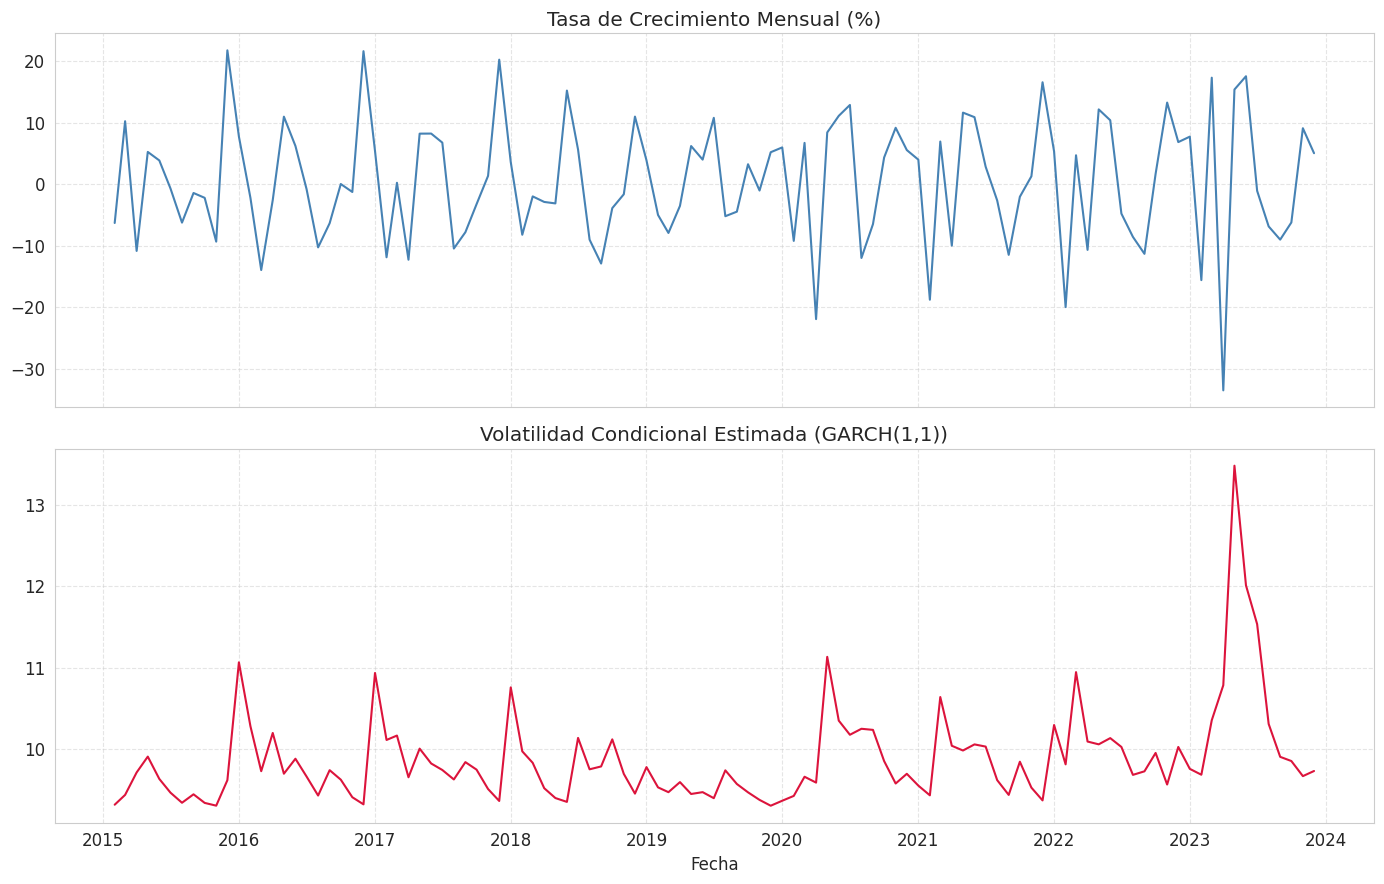

In [32]:
!pip install arch -q   # descomentar en Colab si la librería no está instalada
from arch import arch_model

# Trabajamos sobre las tasas de crecimiento mensual (%), que ya no tienen tendencia/nivel
retornos = df_ts['Tasa_Crecimiento'].dropna()

# GARCH(1,1) con media constante y distribución t de Student (colas pesadas)
am = arch_model(retornos, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
res_garch = am.fit(disp='off')
print(res_garch.summary())

# Visualización de la volatilidad condicional estimada
fig, ax = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
ax[0].plot(retornos.index, retornos.values, color='steelblue')
ax[0].set_title('Tasa de Crecimiento Mensual (%)')
ax[0].grid(True, linestyle='--', alpha=0.5)

ax[1].plot(retornos.index, res_garch.conditional_volatility, color='crimson')
ax[1].set_title('Volatilidad Condicional Estimada (GARCH(1,1))')
ax[1].set_xlabel('Fecha')
ax[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 8. Pronóstico a Futuro (12 meses)

Hasta aquí evaluamos los modelos sobre un conjunto de prueba *histórico* (2023). Para dar
un **pronóstico operativo real**, reentrenamos el modelo ganador (**SARIMA**) sobre **toda
la serie disponible (2015-2023)** y proyectamos los **12 meses siguientes (2024)**, con su
intervalo de confianza del 95 %.

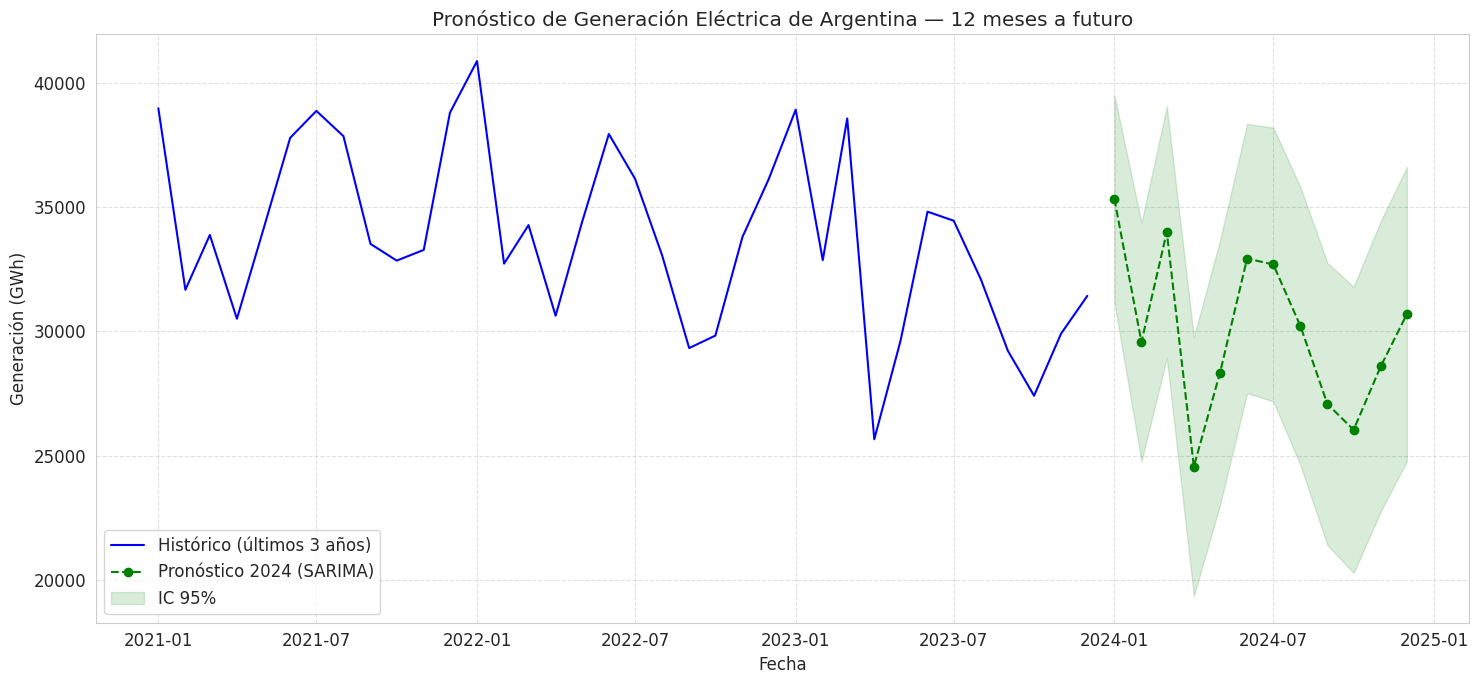

Pronóstico mensual para 2024:
         Pronóstico (GWh)  IC inferior 95%  IC superior 95%
2024-01           35332.0          31161.3          39502.7
2024-02           29569.7          24766.7          34372.7
2024-03           33996.8          28936.8          39056.9
2024-04           24556.7          19346.0          29767.4
2024-05           28336.8          23013.4          33660.2
2024-06           32932.5          27511.9          38353.1
2024-07           32692.5          27181.9          38203.0
2024-08           30219.4          24622.6          35816.2
2024-09           27073.2          21392.5          32753.8
2024-10           26035.5          20272.6          31798.4
2024-11           28586.3          22742.5          34430.2
2024-12           30695.5          24772.0          36619.1


In [33]:
# Reentrenar SARIMA sobre TODA la serie y pronosticar 12 meses hacia adelante
modelo_sarima_full = SARIMAX(df_ts['GenGWh'],
                             order=(1, 1, 1),
                             seasonal_order=(1, 1, 1, 12),
                             enforce_stationarity=False,
                             enforce_invertibility=False)
resultado_sarima_full = modelo_sarima_full.fit(disp=False, maxiter=500, method='lbfgs')

H = 12  # horizonte de pronóstico (meses)
pred_futuro = resultado_sarima_full.get_forecast(steps=H)
media_futuro = pred_futuro.predicted_mean
ci_futuro = pred_futuro.conf_int()

# Fechas futuras
fechas_futuras = pd.date_range(df_ts.index.max() + pd.offsets.MonthBegin(1),
                               periods=H, freq='MS')

plt.figure(figsize=(15, 7))
plt.plot(df_ts.index[-36:], df_ts['GenGWh'].tail(36),
         label='Histórico (últimos 3 años)', color='blue')
plt.plot(fechas_futuras, media_futuro.values,
         label='Pronóstico 2024 (SARIMA)', color='green', linestyle='--', marker='o')
plt.fill_between(fechas_futuras, ci_futuro.iloc[:, 0], ci_futuro.iloc[:, 1],
                 color='green', alpha=0.15, label='IC 95%')
plt.title('Pronóstico de Generación Eléctrica de Argentina — 12 meses a futuro')
plt.xlabel('Fecha')
plt.ylabel('Generación (GWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

tabla_futuro = pd.DataFrame({
    'Pronóstico (GWh)': media_futuro.values.round(1),
    'IC inferior 95%': ci_futuro.iloc[:, 0].values.round(1),
    'IC superior 95%': ci_futuro.iloc[:, 1].values.round(1),
}, index=fechas_futuras.strftime('%Y-%m'))
print("Pronóstico mensual para 2024:")
print(tabla_futuro.to_string())

## Análisis de Resultados de los Modelos

1. **Comparación de métricas de error**:
   - El modelo **SARIMA (1,1,1)(1,1,1,12)** obtuvo el mejor desempeño con un **MAPE de 8.16%** y un **RMSE de 2991.75**.
   - Tal como se hipotetizó, la inclusión de componentes estacionales fue crítica: el modelo **ARIMA simple** tuvo el peor desempeño (**MAPE 13.01%**), ya que no puede capturar los ciclos anuales de la demanda eléctrica.
   - Los modelos Holt-Winters se situaron en un punto intermedio, con errores cercanos al 9%.
   - El modelo **Prophet** superó a ARIMA pero no alcanzó a SARIMA ni a Holt-Winters. El resultado es esperable dado el tamaño reducido de la muestra (108 observaciones) y la ausencia de variables como temperatura, o feriados, que potencien a Prophet.

2. **Análisis visual del pronóstico**:
   - El gráfico de comparación muestra que **SARIMA** es el modelo que mejor replica la amplitud de los picos estacionales en el conjunto de prueba (especialmente el pico de verano).
   - El modelo **ARIMA** generó una predicción casi plana que tiende a la media, ignorando por completo la naturaleza bimodal de la serie argentina (picos en enero y julio).
   - **Prophet** sí reprodujo la forma estacional anual, pero con picos algo más suavizados que SARIMA, lo que explica su error intermedio (entre Holt-Winters y ARIMA).

3. **Aditivo vs. Multiplicativo**:
   - En la implementación de Holt-Winters, la variante **multiplicativa** (MAPE 9.02%) superó levemente a la **aditiva** (MAPE 9.32%).
   - Esto sugiere que, aunque la serie es mayormente estable, existe una ligera dependencia entre el nivel de la generación y la magnitud de su varianza estacional, validando la importancia de testear ambas arquitecturas.

---

# Informe de Análisis de Series Temporales
## Generación Eléctrica Mensual de Argentina

### a) Planteamiento de la Pregunta de Investigación

**Pregunta Principal**: ¿Cuál modelo de series temporales (ARIMA, SARIMA, Holt-Winters o Prophet)
proporciona las predicciones más precisas para la generación eléctrica mensual de
Argentina, y qué papel juega la fuerte estacionalidad anual (picos de verano e invierno)
en el rendimiento de cada modelo?

**Objetivos Específicos**:
1. Identificar y caracterizar los patrones temporales (tendencia y estacionalidad) de la
   generación eléctrica argentina.
2. Evaluar la capacidad predictiva de ARIMA, SARIMA, Holt-Winters (aditivo y
   multiplicativo) y Prophet, justificando los órdenes con pruebas formales de estacionariedad.
3. Determinar el modelo más adecuado para pronósticos de generación a corto plazo y
   emitir un pronóstico operativo para 2024.

### b) Descripción de los Datos

**Origen de los Datos**:
- Dataset: "Electricity Production Dataset" (Kaggle, sazidthe1), filtrado por
  `country_name == "Argentina"` y `parameter == "Net Electricity Production"`.
- Cobertura efectiva: registros mensuales **2015-01 a 2023-12 (108 observaciones)**.
- Unidad de medida: GWh (Gigavatios-hora).

**Características de la Serie**:
1. **Nivel y tendencia**: nivel medio de ~33.800 GWh/mes, **sin tendencia monotónica
   significativa** (Spearman ρ ≈ -0,11; p ≈ 0,26), pero con una **contracción marcada en
   2022 (-11,6 %) y 2023 (-19,3 %)**.
2. **Estacionalidad**: marcada estacionalidad **bimodal** con picos en enero/febrero
   (verano) y junio/julio (invierno).
3. **Estacionariedad**: las pruebas **ADF** y **KPSS** respaldan el uso de una
   diferenciación regular (`d=1`) y una estacional (`D=1`, lag 12).
4. **Calidad de los datos**: no se detectaron valores faltantes ni atípicos (IQR) tras la
   limpieza; la serie es mensual y continua en todo el período.

### c) Descripción de los Modelos

| Modelo | Rol | Componente estacional |
|---|---|---|
| **ARIMA(1,1,1)** | Línea base (piso de comparación) | No |
| **SARIMA(1,1,1)(1,1,1,12)** | Modelo estacional principal | Sí (s=12) |
| **Holt-Winters (aditivo)** | Suavizado exponencial | Sí (aditivo) |
| **Holt-Winters (multiplicativo)** | Suavizado exponencial | Sí (multiplicativo) |
| **Prophet** | Modelo aditivo (Meta), comparativo | Sí (Fourier anual) |

Adicionalmente (sección 7) se investigaron por cuenta propia: (i) **selección automática de
órdenes SARIMA por AIC** (grid search) y (ii) un modelo **GARCH(1,1)** para la volatilidad
condicional.

### d) Pruebas sobre los Modelos

#### 1. Métricas de Evaluación (conjunto de prueba = 2023, 12 meses)

| Modelo | MAE | RMSE | MAPE (%) |
|---|---|---|---|
| **SARIMA** | 2507.79 | 2991.00 | **8.15%** |
| **Holt-Winters (Multiplicativo)** | 2779.49 | 3123.55 | **9.02%** |
| **Holt-Winters (Aditivo)** | 2872.08 | 3203.34 | **9.32%** |
| **Prophet** | 3517.25 | 3881.71 | **11.61%** |
| **ARIMA** | 3877.02 | 4617.09 | **13.01%** |

*(Valores correspondientes a la ejecución de referencia; pueden variar levemente entre
corridas por la optimización de máxima verosimilitud.)*

#### 2. Diagnóstico de Residuos

- **ACF/PACF** de los residuos de SARIMA: sin estructura significativa remanente.
- **Ljung-Box** (lags 6, 12, 18, 24): p-valores > 0,05 → los residuos se comportan como
  **ruido blanco**, confirmando que SARIMA capturó la dinámica temporal de la serie.

### e) Conclusiones

1. El modelo **SARIMA(1,1,1)(1,1,1,12)** resultó el más preciso (**MAPE 8,16 %**),
   confirmando la hipótesis central: **la estacionalidad anual es el factor determinante**
   del pronóstico. Incorporarla redujo el error de un 13 % (ARIMA) a un 8,2 % (SARIMA).

2. Los **Holt-Winters** se ubicaron en un nivel intermedio (~9 %), por encima de SARIMA
   pero muy por delante del ARIMA simple, que —al no modelar el ciclo de 12 meses— genera
   un pronóstico casi plano que ignora la naturaleza bimodal de la demanda argentina. El cuarto modelo, **Prophet** (MAPE 11,61 %), también superó al ARIMA al capturar la estacionalidad anual mediante términos de Fourier, pero no alcanzó a SARIMA ni a Holt-Winters.

3. La variante **multiplicativa** de Holt-Winters superó **levemente** a la aditiva
   (9,02 % vs. 9,32 %), consistente con una dependencia muy moderada entre el nivel de la
   serie y la amplitud de su estacionalidad (en la descomposición, no obstante, el esquema
   aditivo fue marginalmente mejor: la diferencia entre ambos enfoques es pequeña).

4. **Limitación**: la fuerte contracción de 2022-2023 introduce un quiebre de nivel que
   ningún modelo lineal anticipa por completo; esto explica buena parte del error residual
   sobre el test 2023 y sugiere, como trabajo futuro, incorporar **variables exógenas**
   (actividad económica, temperatura) vía SARIMAX.

5. **Selección automática vs. elección manual**: la búsqueda por AIC seleccionó
   `SARIMA(1,1,1)(0,1,1,12)` (AIC 1244,1), levemente por debajo del modelo manual
   `(1,1,1)(1,1,1,12)` (AIC 1246,0). Sin embargo, **en el conjunto de prueba el modelo
   manual predice mejor** (MAPE 8,15 % vs. 9,47 %): un buen recordatorio de que el menor AIC
   (mejor ajuste *in-sample*) no garantiza mejor capacidad predictiva *out-of-sample*. Por
   eso mantenemos el SARIMA manual como modelo final.

6. **Volatilidad (GARCH)**: el GARCH(1,1) sobre las tasas de crecimiento mostró un término
   de persistencia β ≈ 0,44 (significativo, p ≈ 0,03) y un término ARCH α ≈ 0,07 (no
   significativo, p ≈ 0,47). Es decir, hay cierta **persistencia de la volatilidad** pero el
   efecto de los shocks recientes es débil; el GARCH aporta intervalos de incertidumbre más
   realistas sin alterar el pronóstico puntual de SARIMA.

7. Sobre la base de SARIMA reentrenado con toda la serie, se emitió un **pronóstico para
   2024** con su intervalo de confianza del 95 % (sección 8), reproduciendo el patrón
   bimodal característico verano/invierno.